# 🦸 Comic Books Dataset — From Panels to Patterns
### A Complete Data Science Journey: Basic → Advanced Analysis

> **Dataset:** [Comic Books Dataset (10,000 entries)](https://www.kaggle.com/datasets/rudrakumargupta/comic-books-dataset-10000-entries)

---

## 📖 Table of Contents
1. [Setup & Imports](#1-setup)
2. [Data Loading & Overview](#2-data-loading)
3. [Data Cleaning & Feature Engineering](#3-data-cleaning)
4. [📊 Basic Analysis](#4-basic-analysis)
   - 4.1 Publisher Distribution
   - 4.2 Genre Breakdown
   - 4.3 Numerical Distributions
   - 4.4 Correlation Heatmap
5. [📈 Intermediate Analysis](#5-intermediate-analysis)
   - 5.1 Publisher vs Avg Rating
   - 5.2 Decade-by-Decade Trends
   - 5.3 Rating vs Pages Scatter
   - 5.4 Most Prolific Writers & Artists
   - 5.5 Genre × Publisher Heatmap
   - 5.6 Age Rating & Status
   - 5.7 Country & Language
   - 5.8 Era & Theme Analysis
6. [🔬 Advanced Analysis](#6-advanced-analysis)
   - 6.1 NLP: TF-IDF + WordCloud
   - 6.2 KMeans Clustering + PCA
   - 6.3 Rating Prediction (4 Models)
   - 6.4 Content-Based Recommender
   - 6.5 Title Similarity by Publisher
   - 6.6 Publication Volume Over Time
7. [💡 Key Insights & Conclusions](#7-insights)

---


## 1. Setup & Imports <a id='1-setup'></a>

In [111]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# ── NLP ───────────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# ── Stats ─────────────────────────────────────────────────────────────────────
from scipy import stats

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Recommender ───────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

# ── Style Configuration ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor':   '#161B22',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#C9D1D9',
    'ytick.color':      '#C9D1D9',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'font.family':      'DejaVu Sans',
    'figure.dpi':       130,
})

PALETTE   = ['#58A6FF','#F78166','#3FB950','#D2A8FF','#FFA657','#79C0FF']
HERO_BLUE = '#58A6FF'
HERO_RED  = '#F78166'
HERO_GRN  = '#3FB950'

print("✅ All imports successful!")
print(f"   NumPy {np.__version__}  |  Pandas {pd.__version__}")


✅ All imports successful!
   NumPy 2.0.2  |  Pandas 2.3.3


## 2. Data Loading & Overview <a id='2-data-loading'></a>

In [112]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/rudrakumargupta/comic-books-dataset-10000-entries/comic_books_10000_dataset.csv')

print(f"📚 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("─" * 50)
df.head(3)

📚 Dataset Shape: 10,000 rows × 17 columns
──────────────────────────────────────────────────


,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,890,8.0,Ongoing,Japanese,Mature,NaN,13
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,2850,8.3,Completed,Japanese,Mature,NaN,12
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,350,7.8,Ongoing,English,Teen+,Japan Media Arts Award Winner,13


In [113]:
# ── Data Types & Memory ───────────────────────────────────────────────────────
print("Column Info:")
print(df.dtypes.to_string())
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Column Info:
comic_id                object
Title                   object
Writer                  object
Artist                  object
Studio/Publisher        object
Release Year             int64
Format                  object
Theme (Color Style)     object
Genre                   object
Country of Origin       object
Page Count               int64
Rating (out of 10)     float64
Status                  object
Language                object
Age Rating              object
Awards                  object
Volume Count             int64

Memory Usage: 7865.8 KB


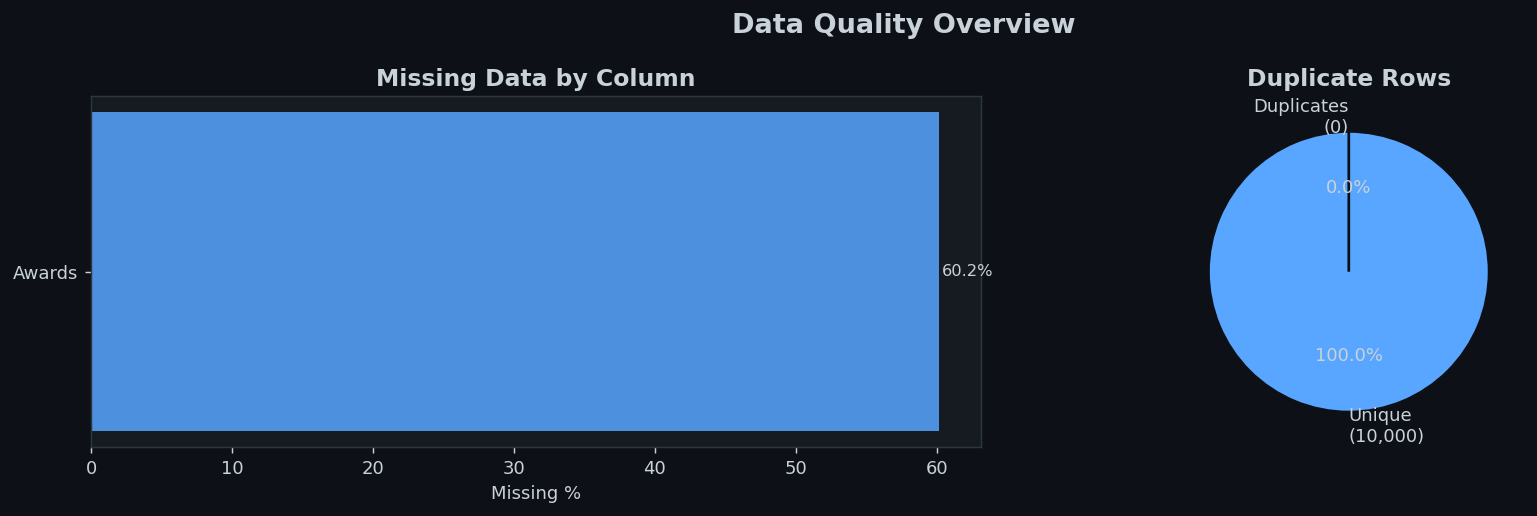


📊 Dataset Summary:
   Rows: 10,000  |  Columns: 17
   Missing cells: 6,016  |  Duplicate rows: 0


In [114]:
# ── Missing Value Heatmap ─────────────────────────────────────────────────────
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Data Quality Overview', fontsize=15, fontweight='bold')   # ← BEFORE tight_layout

if len(missing_df) > 0:
    bars = axes[0].barh(missing_df.index, missing_df['Missing %'], color=HERO_BLUE, alpha=0.85)
    axes[0].set_xlabel('Missing %')
    axes[0].set_title('Missing Data by Column', fontweight='bold', fontsize=13)
    for bar, val in zip(bars, missing_df['Missing %']):
        axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, '🎉 No Missing Values!', ha='center', va='center',
                 fontsize=16, color=HERO_GRN, transform=axes[0].transAxes)
    axes[0].set_title('Missing Data', fontweight='bold')
    axes[0].axis('off')

dup_count = df.duplicated().sum()
axes[1].pie(
    [len(df) - dup_count, max(dup_count, 0)],
    labels=[f'Unique\n({len(df)-dup_count:,})', f'Duplicates\n({dup_count})'],
    colors=[HERO_BLUE, HERO_RED], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0D1117', 'linewidth': 1.5}
)
axes[1].set_title('Duplicate Rows', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print(f"\n📊 Dataset Summary:")
print(f"   Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"   Missing cells: {df.isnull().sum().sum():,}  |  Duplicate rows: {dup_count}")


In [115]:
# ── Quick Stats ───────────────────────────────────────────────────────────────
df.describe(include='all').round(2)

,comic_id,Title,Writer,Artist,Studio/Publisher,Release Year,Format,Theme (Color Style),Genre,Country of Origin,Page Count,Rating (out of 10),Status,Language,Age Rating,Awards,Volume Count
count,10000,10000,10000,10000,10000,10000.00,10000,10000,10000,10000,10000.00,10000.00,10000,10000,10000,3984,10000.00
unique,10000,8158,327,343,111,NaN,20,8,105,21,NaN,NaN,4,8,5,15,NaN
top,CMC-09984,Noise Road,Ed Brubaker,Ed Brubaker,Marvel Comics,NaN,Tankobon,Black & White,Horror / Supernatural,Japan,NaN,NaN,Completed,English,Teen+,Harvey Award Winner,NaN
freq,1,9,80,81,1218,NaN,906,3143,295,3575,NaN,NaN,5005,4146,3996,371,NaN
mean,NaN,NaN,NaN,NaN,NaN,2015.50,NaN,NaN,NaN,NaN,2232.87,8.06,NaN,NaN,NaN,NaN,13.67
std,NaN,NaN,NaN,NaN,NaN,7.44,NaN,NaN,NaN,NaN,1866.72,0.53,NaN,NaN,NaN,NaN,11.36
min,NaN,NaN,NaN,NaN,NaN,2000.00,NaN,NaN,NaN,NaN,48.00,6.00,NaN,NaN,NaN,NaN,1.00
25%,NaN,NaN,NaN,NaN,NaN,2010.00,NaN,NaN,NaN,NaN,748.75,7.70,NaN,NaN,NaN,NaN,5.00
50%,NaN,NaN,NaN,NaN,NaN,2017.00,NaN,NaN,NaN,NaN,1571.00,8.10,NaN,NaN,NaN,NaN,10.00
75%,NaN,NaN,NaN,NaN,NaN,2022.00,NaN,NaN,NaN,NaN,3511.00,8.40,NaN,NaN,NaN,NaN,19.00


## 3. Data Cleaning <a id='3-data-cleaning'></a>

In [116]:
df_clean = df.copy()

# ── Standardise column names ──────────────────────────────────────────────────
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s/]+', '_', regex=True)
)

# ── Rename actual dataset columns → standard names ────────────────────────────
rename_map = {
    # Publisher
    'studio_publisher':   'publisher',
    'publisher':          'publisher',
    # Year
    'release_year':       'year',
    'publication_year':   'year',
    'year':               'year',
    # Pages
    'page_count':         'pages',
    'num_pages':          'pages',
    'pages':              'pages',
    # Rating
    'rating_(out_of_10)': 'rating',
    'user_rating':        'rating',
    'rating':             'rating',
    # Price (not in this dataset but keep for safety)
    'price_usd':          'price',
    'cover_price':        'price',
    'price':              'price',
    # Theme
    'theme_(color_style)':'theme',
    # Country
    'country_of_origin':  'country',
    'country':            'country',
    # Volume
    'volume_count':       'volume_count',
}
df_clean = df_clean.rename(columns={k: v for k, v in rename_map.items() if k in df_clean.columns})

# ── Numeric coercion ──────────────────────────────────────────────────────────
for col in ['price', 'rating', 'pages', 'year', 'issue_number', 'volume_count']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# ── Drop duplicates ───────────────────────────────────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean)} duplicate rows.")

# ── Feature Engineering ───────────────────────────────────────────────────────
if 'year' in df_clean.columns:
    df_clean['decade'] = (df_clean['year'] // 10 * 10).astype('Int64')
    df_clean['era'] = pd.cut(
        df_clean['year'],
        bins=[0, 1950, 1969, 1985, 1999, 2010, 2030],
        labels=['Golden Age','Silver Age','Bronze Age',
                'Modern Age','21st Century','Contemporary']
    )

if 'rating' in df_clean.columns:
    # Bins aligned to actual data range (6.0 – 9.9) confirmed from describe()
    df_clean['rating_label'] = pd.cut(
        df_clean['rating'],
        bins=[0, 6.5, 7.5, 8.5, 10],
        labels=['Below Average', 'Average', 'Good', 'Excellent']
    )

if 'price' in df_clean.columns:
    df_clean['price_bucket'] = pd.qcut(
        df_clean['price'].dropna(), q=4,
        labels=['Budget','Mid-Range','Premium','Collector'],
        duplicates='drop'
    )

if 'title' in df_clean.columns:
    df_clean['title_word_count'] = df_clean['title'].str.split().str.len()

print(f"\n✅ Cleaned dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print("\n📋 Final columns:", df_clean.columns.tolist())
df_clean.head(3)


Removed 0 duplicate rows.

✅ Cleaned dataset: 10,000 rows × 21 columns

📋 Final columns: ['comic_id', 'title', 'writer', 'artist', 'publisher', 'year', 'format', 'theme', 'genre', 'country', 'pages', 'rating', 'status', 'language', 'age_rating', 'awards', 'volume_count', 'decade', 'era', 'rating_label', 'title_word_count']


,comic_id,title,writer,artist,publisher,year,format,theme,genre,country,...,rating,status,language,age_rating,awards,volume_count,decade,era,rating_label,title_word_count
0,CMC-00001,Tiger of Zero,Gintoki Sakata,Gintoki Sakata,Shogakukan (Viz Media),2001,Tankobon,Full Color (Special Edition),Shoujo / Romance,Japan,...,8.0,Ongoing,Japanese,Mature,NaN,13,2000,21st Century,Good,3
1,CMC-00002,Twisted Claw,Fumi Takahashi,Mika Sasaki,Shogakukan (Viz Media),2015,Tankobon,Black & White,Action / Historical,Japan,...,8.3,Completed,Japanese,Mature,NaN,12,2010,Contemporary,Good,2
2,CMC-00003,Jean Grey: Rebirth,Chip Zdarsky,Bendis,Marvel Comics,2016,Graphic Novel,Full Color,Superhero / Thriller,USA,...,7.8,Ongoing,English,Teen+,Japan Media Arts Award Winner,13,2010,Contemporary,Good,3


## 4. 📊 Basic Analysis <a id='4-basic-analysis'></a>

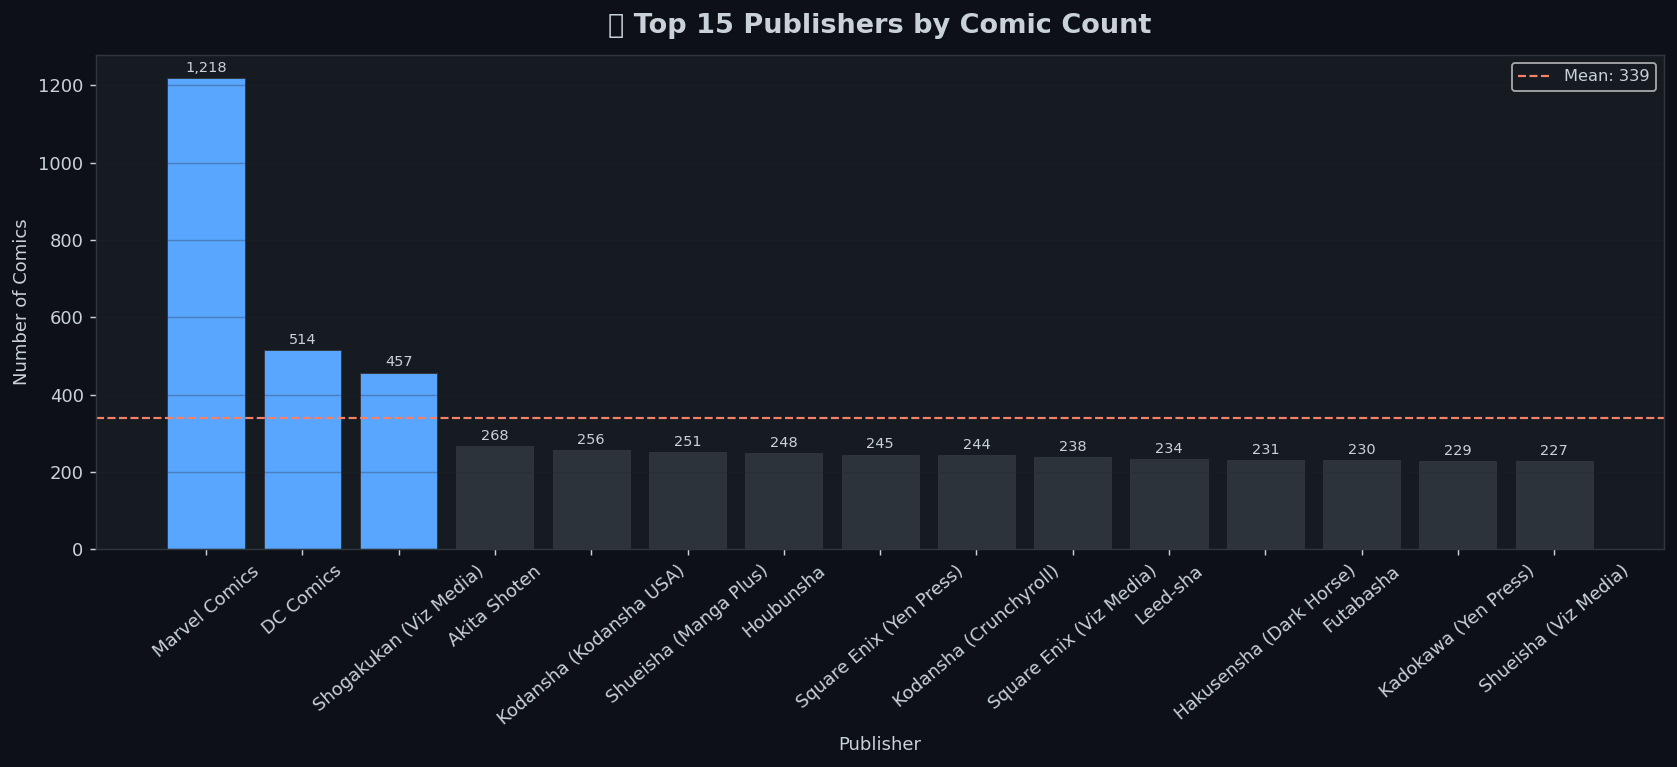


Top 5 Publishers:
publisher
Marvel Comics              1218
DC Comics                   514
Shogakukan (Viz Media)      457
Akita Shoten                268
Kodansha (Kodansha USA)     256


In [117]:
# ── 4.1  Publisher Distribution ───────────────────────────────────────────────
if 'publisher' in df_clean.columns:
    pub_counts = df_clean['publisher'].value_counts().head(15)
    mean_count = pub_counts.mean()

    fig, ax = plt.subplots(figsize=(13, 6))
    # Highlight publishers above the average count
    colors = [HERO_BLUE if v >= mean_count else '#2D333B' for v in pub_counts.values]
    bars = ax.bar(pub_counts.index, pub_counts.values, color=colors,
                  edgecolor='#30363D', linewidth=0.5)

    ax.axhline(mean_count, color=HERO_RED, linestyle='--', linewidth=1.2,
               label=f'Mean: {mean_count:.0f}')

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 8,
                f'{int(h):,}', ha='center', va='bottom', fontsize=8, color='#C9D1D9')

    ax.set_title('📚 Top 15 Publishers by Comic Count', fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel('Publisher')
    ax.set_ylabel('Number of Comics')
    ax.tick_params(axis='x', rotation=40)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print("\nTop 5 Publishers:")
    print(pub_counts.head(5).to_string())
else:
    print("⚠️  Column 'publisher' not found. Available:", df_clean.columns.tolist())


In [118]:
# ── 4.2  Genre Breakdown ──────────────────────────────────────────────────────
if 'genre' in df_clean.columns:
    genre_counts = df_clean['genre'].value_counts().head(12)

    fig = px.pie(
        values=genre_counts.values,
        names=genre_counts.index,
        title='🎭 Genre Distribution',
        color_discrete_sequence=px.colors.qualitative.Bold,
        hole=0.4
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.update_layout(
        paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
        font_color='#C9D1D9', title_font_size=18
    )
    fig.show()

Numeric columns found: ['rating', 'pages', 'year', 'volume_count']


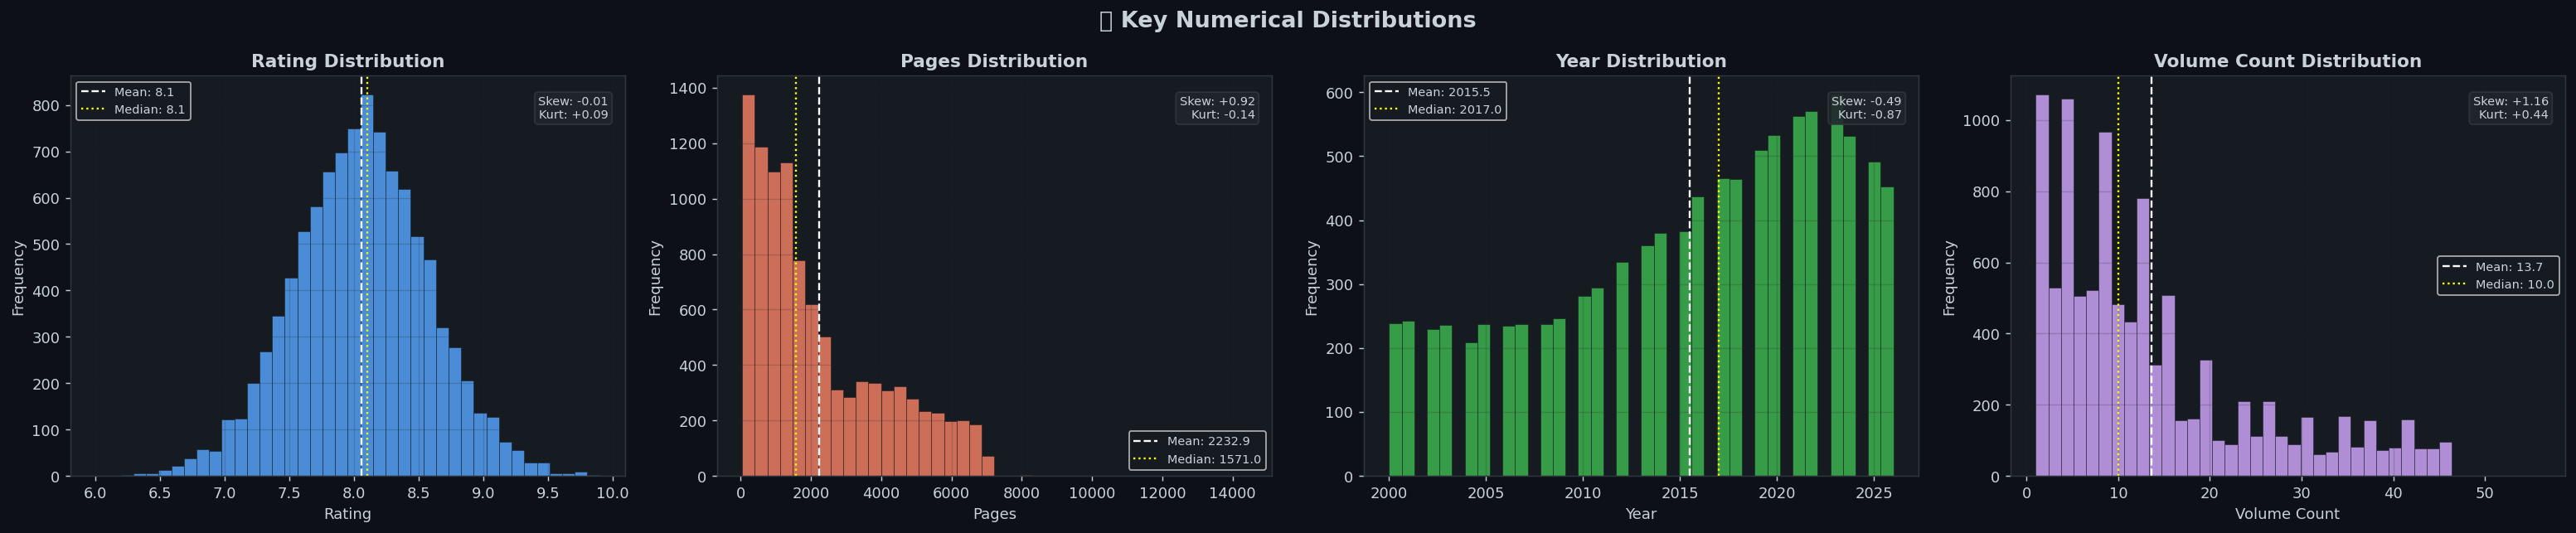


📋 Summary Statistics:
          rating     pages     year  volume_count
Mean        8.06   2232.87  2015.50         13.67
Median      8.10   1571.00  2017.00         10.00
Std         0.53   1866.72     7.44         11.36
Min         6.00     48.00  2000.00          1.00
Max         9.90  14400.00  2026.00         56.00
Skewness   -0.01      0.92    -0.49          1.16
Kurtosis    0.09     -0.14    -0.87          0.44


In [119]:
# ── 4.3  Numerical Distributions with Skewness ────────────────────────────────
num_cols = [c for c in ['rating', 'pages', 'year', 'volume_count'] if c in df_clean.columns]
n = len(num_cols)
print(f"Numeric columns found: {num_cols}")

if n == 0:
    print("⚠️  No numeric columns found:", df_clean.columns.tolist())
else:
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    fig.suptitle('📊 Key Numerical Distributions', fontsize=15, fontweight='bold')
    if n == 1:
        axes = [axes]

    colors_dist = [HERO_BLUE, HERO_RED, HERO_GRN, '#D2A8FF']
    for ax, col, color in zip(axes, num_cols, colors_dist):
        data = df_clean[col].dropna()
        skew_val = data.skew()
        kurt_val = data.kurt()

        ax.hist(data, bins=40, color=color, alpha=0.82, edgecolor='#0D1117', linewidth=0.3)
        ax.axvline(data.mean(),   color='white',  linestyle='--', linewidth=1.3,
                   label=f'Mean: {data.mean():.1f}')
        ax.axvline(data.median(), color='yellow', linestyle=':',  linewidth=1.3,
                   label=f'Median: {data.median():.1f}')

        ax.set_title(f'{col.replace("_"," ").title()} Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

        ax.text(0.97, 0.95, f'Skew: {skew_val:+.2f}\nKurt: {kurt_val:+.2f}',
                transform=ax.transAxes, fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262D',
                          edgecolor='#30363D', alpha=0.9))

    plt.tight_layout()
    plt.show()

    # ── Summary stats — use named functions to avoid lambda name collision ────
    def skewness(x): return x.skew()
    def kurtosis(x): return x.kurt()

    stats_df = df_clean[num_cols].agg(['mean','median','std','min','max', skewness, kurtosis])
    stats_df.index = ['Mean','Median','Std','Min','Max','Skewness','Kurtosis']
    print("\n📋 Summary Statistics:")
    print(stats_df.round(2).to_string())


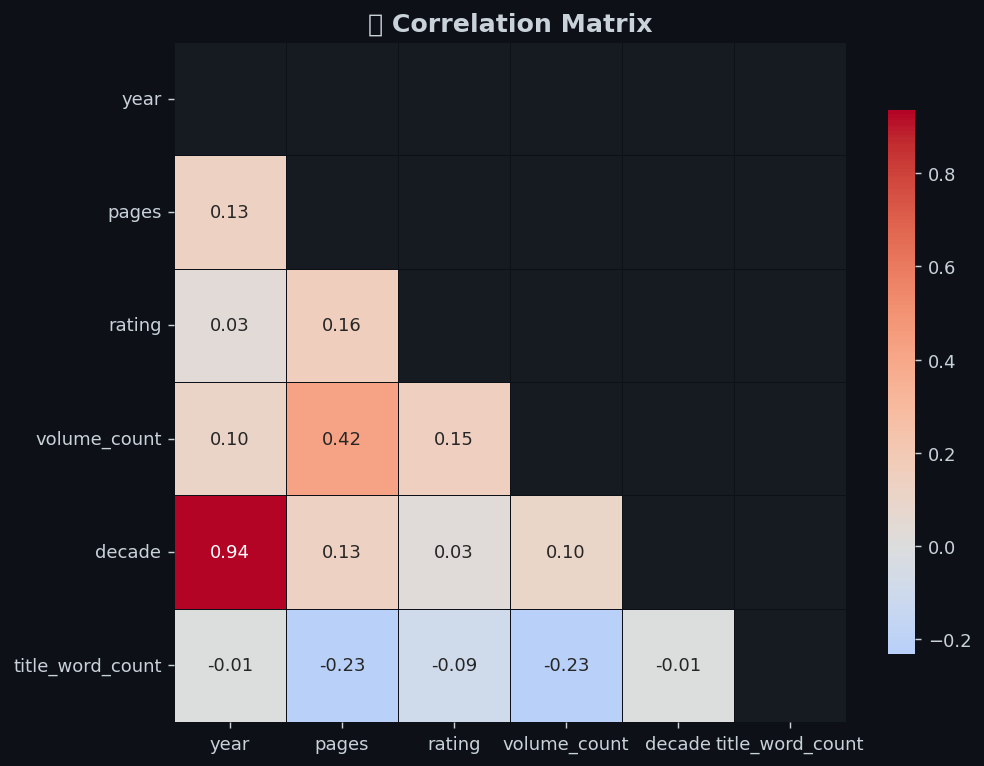

In [120]:
# ── 4.4  Correlation Heatmap ──────────────────────────────────────────────────
num_df = df_clean.select_dtypes(include='number')
if len(num_df.columns) > 1:
    corr = num_df.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5, linecolor='#0D1117',
                cbar_kws={'shrink': 0.8})
    ax.set_title('🔥 Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. 📈 Intermediate Analysis <a id='5-intermediate-analysis'></a>

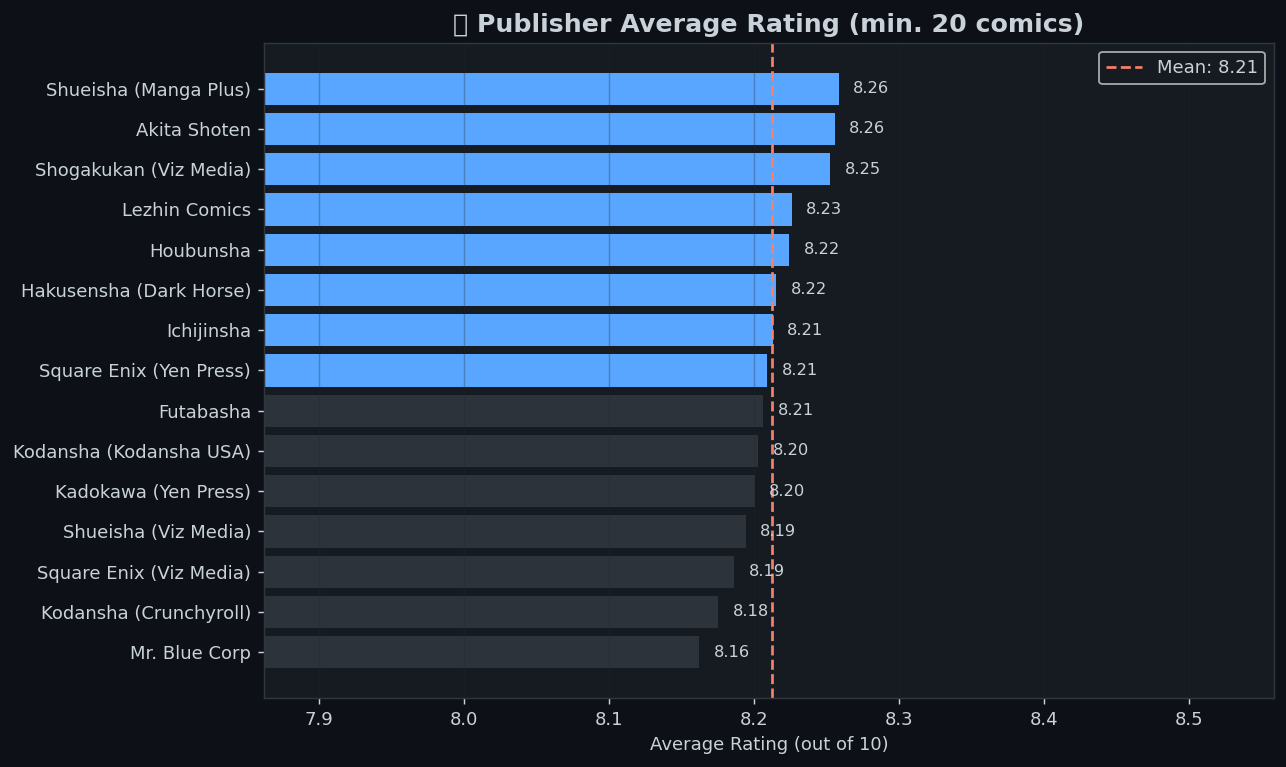

In [121]:
# ── 5.1  Publisher vs Avg Rating ──────────────────────────────────────────────
if 'publisher' in df_clean.columns and 'rating' in df_clean.columns:
    pub_rating = (
        df_clean.groupby('publisher')
        .agg(avg_rating=('rating','mean'), count=('rating','count'))
        .query('count >= 20')
        .sort_values('avg_rating', ascending=True)
        .tail(15)
    )

    if len(pub_rating) == 0:
        pub_rating = (
            df_clean.groupby('publisher')
            .agg(avg_rating=('rating','mean'), count=('rating','count'))
            .query('count >= 5')
            .sort_values('avg_rating', ascending=True)
            .tail(15)
        )

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        pub_rating.index, pub_rating['avg_rating'],
        color=[HERO_BLUE if v >= pub_rating['avg_rating'].median()
               else '#2D333B' for v in pub_rating['avg_rating']]
    )
    ax.axvline(pub_rating['avg_rating'].mean(), color=HERO_RED, linestyle='--',
               linewidth=1.5, label=f'Mean: {pub_rating["avg_rating"].mean():.2f}')

    # ✅ Set xlim just below the minimum so small differences are visible
    x_min = max(0, pub_rating['avg_rating'].min() - 0.3)
    x_max = pub_rating['avg_rating'].max() + 0.3
    ax.set_xlim(x_min, x_max)

    ax.set_title('⭐ Publisher Average Rating (min. 20 comics)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Rating (out of 10)')
    ax.legend()
    for bar, val in zip(bars, pub_rating['avg_rating']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Missing columns. Available:", df_clean.columns.tolist())


In [122]:
# ── 5.2  Decade-by-Decade Publication Trends ──────────────────────────────────
if 'decade' in df_clean.columns:
    agg_dict = {'count': ('title','count')}
    if 'rating' in df_clean.columns:
        agg_dict['avg_rating'] = ('rating','mean')

    decade_data = (
        df_clean.groupby('decade')
        .agg(**agg_dict)
        .dropna()
        .reset_index()
    )
    decade_data = decade_data[decade_data['decade'].notna()]

    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig.add_trace(
        go.Bar(x=decade_data['decade'].astype(str),
               y=decade_data['count'],
               name='Comic Count', marker_color=HERO_BLUE, opacity=0.8),
        secondary_y=False
    )
    if 'avg_rating' in decade_data.columns:
        fig.add_trace(
            go.Scatter(x=decade_data['decade'].astype(str),
                       y=decade_data['avg_rating'],
                       name='Avg Rating', line=dict(color=HERO_RED, width=2.5),
                       mode='lines+markers'),
            secondary_y=True
        )
    fig.update_layout(
        title='📅 Comics Published Per Decade + Avg Rating Trend',
        paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
        font_color='#C9D1D9', title_font_size=16,
        xaxis_title='Decade'
    )
    fig.update_yaxes(title_text='Number of Comics', secondary_y=False)
    fig.update_yaxes(title_text='Average Rating', secondary_y=True)
    fig.show()
else:
    print("⚠️  'decade' column missing — rerun the cleaning cell first.")


In [123]:
# ── 5.3  Rating vs Pages Scatter ──────────────────────────────────────────────
# Note: dataset has no price column — using pages vs rating instead
if 'pages' in df_clean.columns and 'rating' in df_clean.columns:
    color_col = 'publisher' if 'publisher' in df_clean.columns else 'genre'
    top_cats  = df_clean[color_col].value_counts().head(6).index

    plot_df = (
        df_clean[df_clean[color_col].isin(top_cats)]
        [['pages', 'rating', color_col]]
        .dropna()
    )
    # ✅ Safe sample: never request more rows than available
    n_sample = min(3000, len(plot_df))
    if n_sample > 0:
        plot_df = plot_df.sample(n_sample, random_state=42)

    fig = px.scatter(
        plot_df, x='pages', y='rating', color=color_col,
        title='📖 Page Count vs Rating by Publisher',
        opacity=0.65, trendline='ols',
        color_discrete_sequence=px.colors.qualitative.Bold,
        labels={'pages': 'Page Count', 'rating': 'Rating (out of 10)'}
    )
    fig.update_layout(
        paper_bgcolor='#0D1117', plot_bgcolor='#161B22', font_color='#C9D1D9'
    )
    fig.show()
    print(f"Plotted {len(plot_df):,} data points.")

elif 'rating' in df_clean.columns and 'genre' in df_clean.columns:
    top_genres = df_clean['genre'].value_counts().head(8).index
    plot_df    = df_clean[df_clean['genre'].isin(top_genres)]

    fig = px.box(
        plot_df, x='genre', y='rating', color='genre',
        title='🎭 Rating Distribution by Genre',
        color_discrete_sequence=px.colors.qualitative.Bold
    )
    fig.update_layout(
        paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
        font_color='#C9D1D9', showlegend=False
    )
    fig.show()

else:
    print("⚠️  Needed columns not found. Available:", df_clean.columns.tolist())


Plotted 2,964 data points.


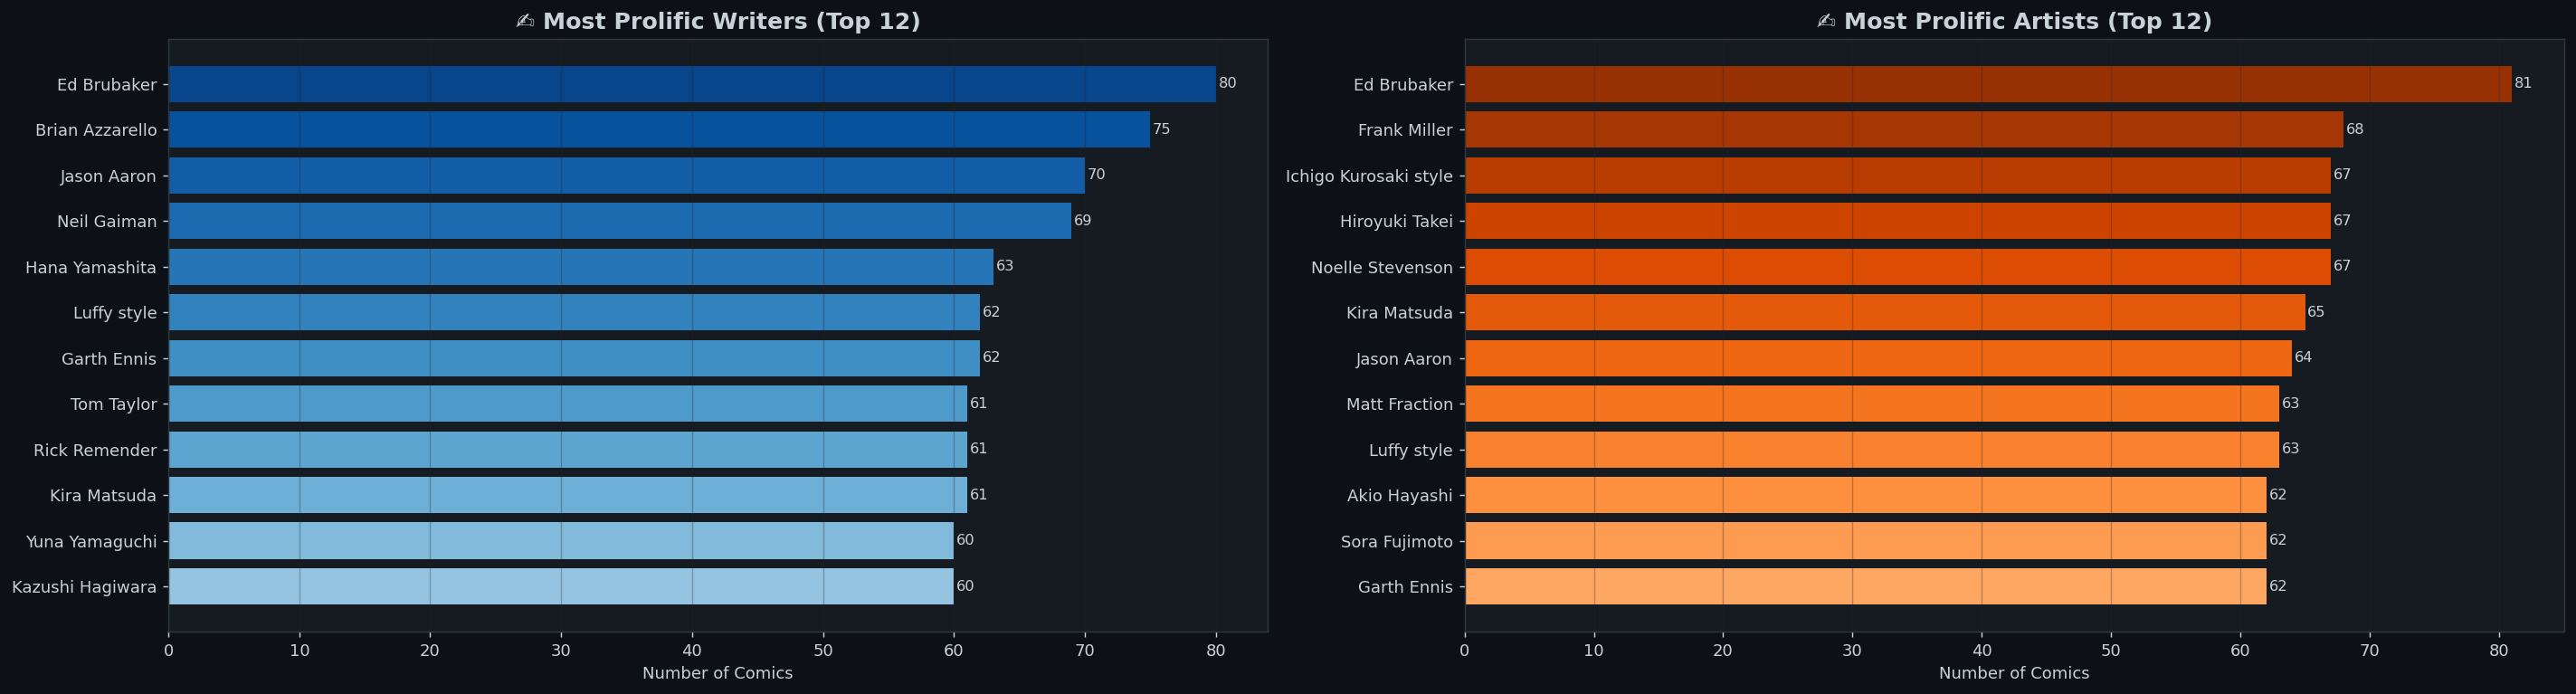

In [124]:
# ── 5.4  Most Prolific Writers & Artists ─────────────────────────────────────
role_cols = [c for c in ['writer', 'artist'] if c in df_clean.columns]

if not role_cols:
    print("⚠️  No writer/artist columns found.")
else:
    fig, axes = plt.subplots(1, len(role_cols), figsize=(11 * len(role_cols), 6))
    if len(role_cols) == 1:
        axes = [axes]

    cmaps = [plt.cm.Blues, plt.cm.Oranges]
    for ax, role_col, cmap in zip(axes, role_cols, cmaps):
        top_people = df_clean[role_col].value_counts().head(12)
        colors_bar = cmap(np.linspace(0.4, 0.92, len(top_people)))
        bars = ax.barh(top_people.index[::-1], top_people.values[::-1], color=colors_bar)

        for bar, val in zip(bars, top_people.values[::-1]):
            ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontsize=9, color='#C9D1D9')

        ax.set_title(f'✍️ Most Prolific {role_col.title()}s (Top 12)',
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Number of Comics')
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


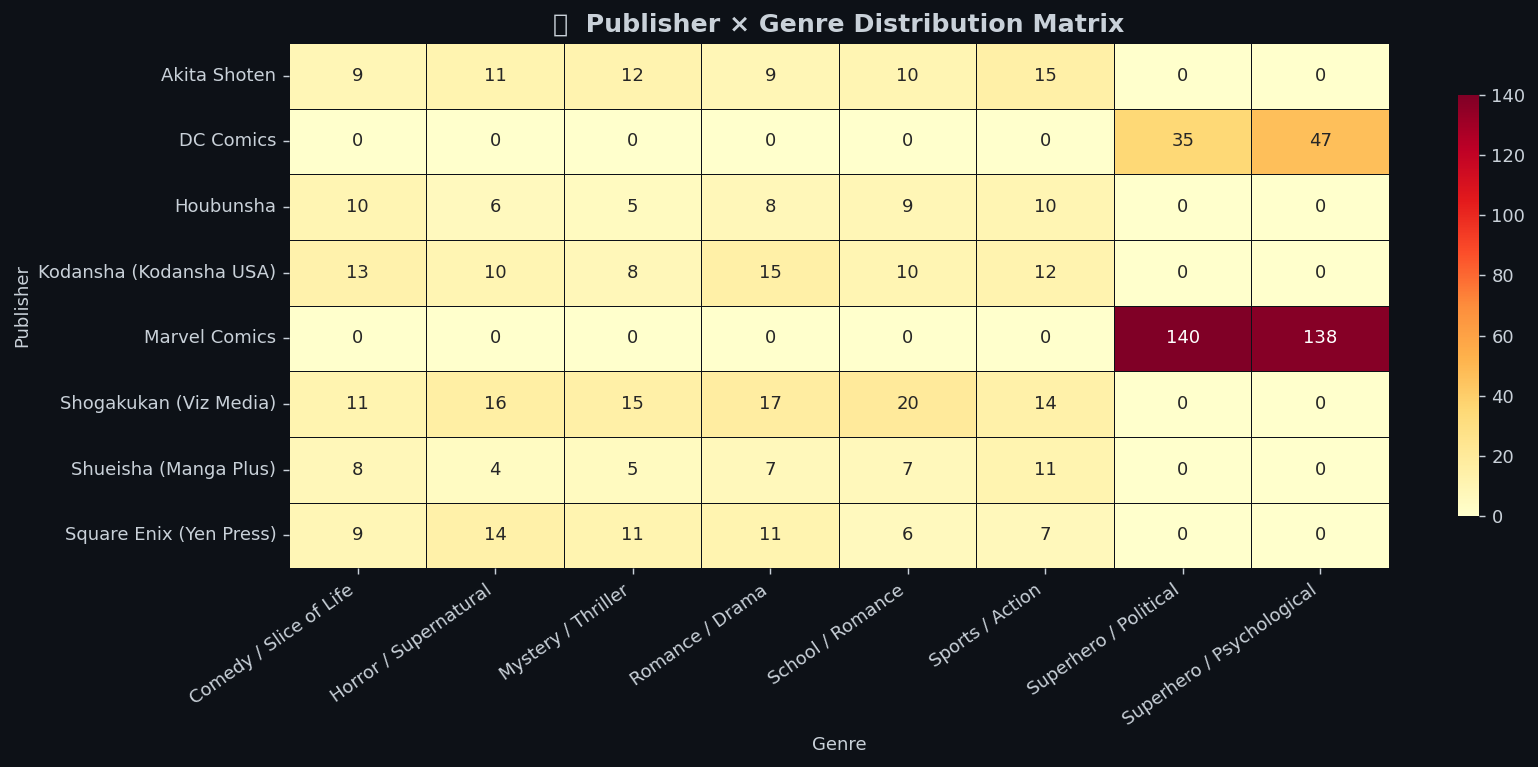

In [125]:
# ── 5.5  Genre × Publisher Heatmap ───────────────────────────────────────────
if 'genre' in df_clean.columns and 'publisher' in df_clean.columns:
    top_pubs   = df_clean['publisher'].value_counts().head(8).index
    top_genres = df_clean['genre'].value_counts().head(8).index

    heat_data = (
        df_clean[
            df_clean['publisher'].isin(top_pubs) &
            df_clean['genre'].isin(top_genres)
        ]
        .groupby(['publisher','genre'])
        .size()
        .unstack(fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                linewidths=0.4, linecolor='#0D1117',
                cbar_kws={'shrink': 0.8})
    ax.set_title('🗺️  Publisher × Genre Distribution Matrix',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Genre')
    ax.set_ylabel('Publisher')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Missing columns. Available:", df_clean.columns.tolist())


### 5.6 – 5.8  Deep-Dive: Classification, Geography & Eras

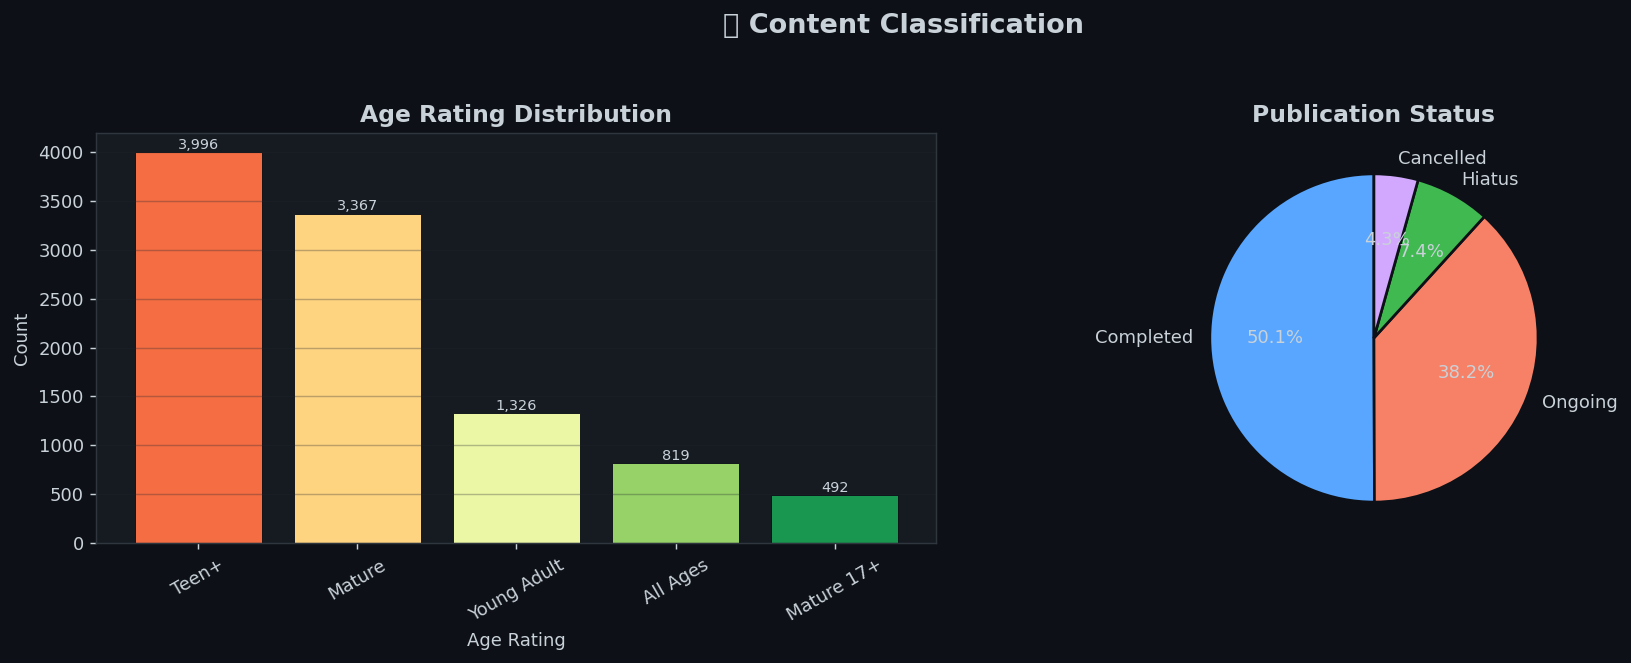


🏆 Awards: 3,984 comics have award entries | 15 unique awards


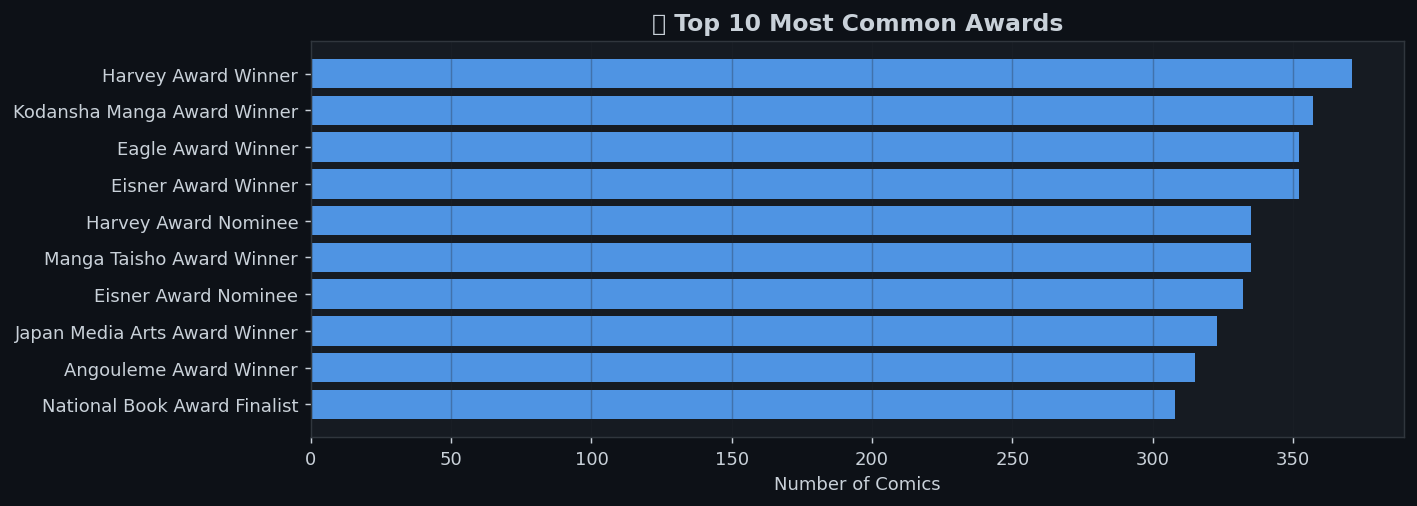

In [126]:
# ── 5.6  Age Rating & Status Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📋 Content Classification', fontsize=15, fontweight='bold', y=1.01)

# Age Rating
if 'age_rating' in df_clean.columns:
    age_counts = df_clean['age_rating'].value_counts()
    colors_age = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(age_counts)))
    bars = axes[0].bar(age_counts.index, age_counts.values, color=colors_age,
                       edgecolor='#0D1117', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 5,
                     f'{int(h):,}', ha='center', va='bottom', fontsize=8)
    axes[0].set_title('Age Rating Distribution', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Age Rating')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].grid(axis='y', alpha=0.3)

# Status
if 'status' in df_clean.columns:
    status_counts = df_clean['status'].value_counts()
    wedge_props   = {'edgecolor': '#0D1117', 'linewidth': 1.5}
    axes[1].pie(status_counts.values, labels=status_counts.index,
                autopct='%1.1f%%', startangle=90,
                colors=PALETTE[:len(status_counts)],
                wedgeprops=wedge_props)
    axes[1].set_title('Publication Status', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Awards analysis
if 'awards' in df_clean.columns:
    total_awarded = df_clean['awards'].notna().sum()
    unique_awards = df_clean['awards'].nunique()
    print(f"\n🏆 Awards: {total_awarded:,} comics have award entries | {unique_awards} unique awards")

    top_awards = df_clean['awards'].value_counts().head(10)
    if len(top_awards) > 0:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.barh(top_awards.index[::-1], top_awards.values[::-1],
                color=HERO_BLUE, alpha=0.88)
        ax.set_title('🏆 Top 10 Most Common Awards', fontsize=13, fontweight='bold')
        ax.set_xlabel('Number of Comics')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()


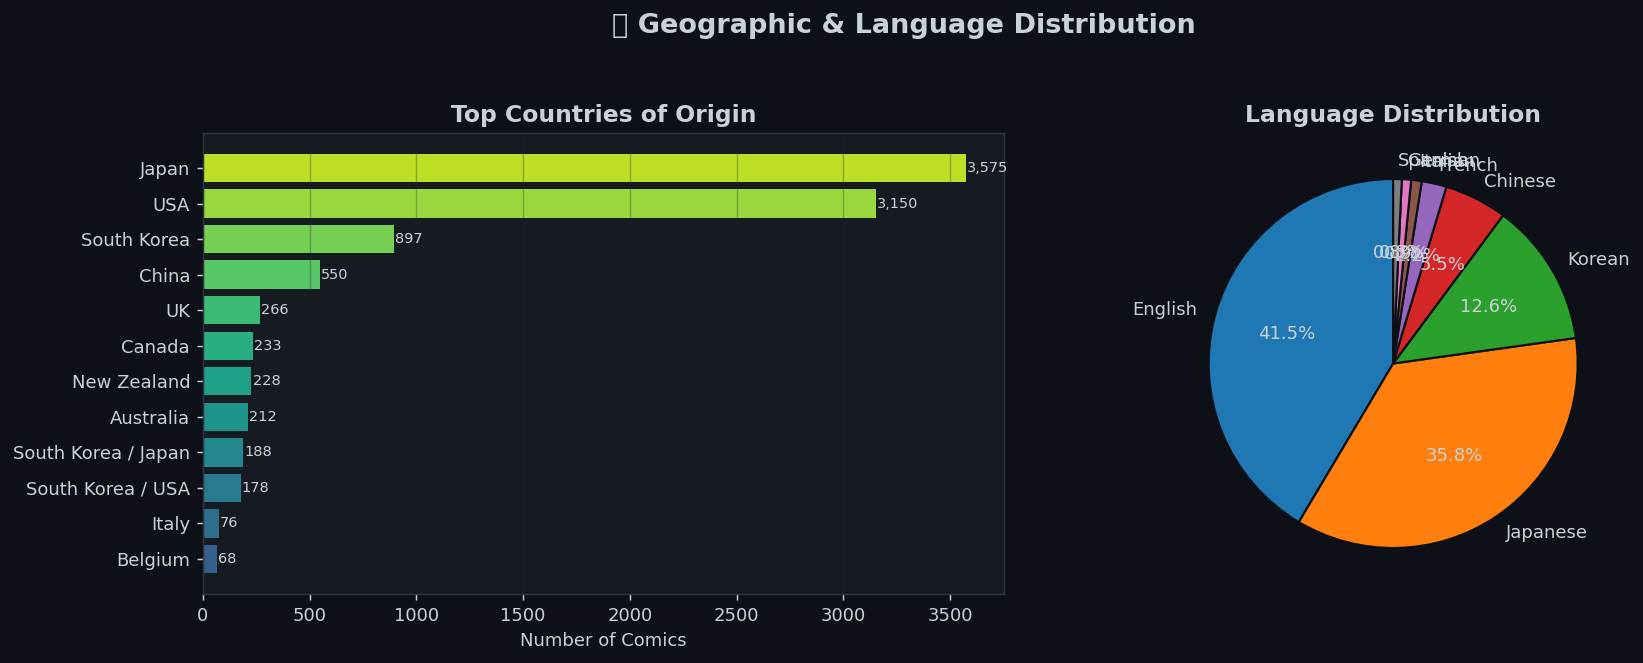

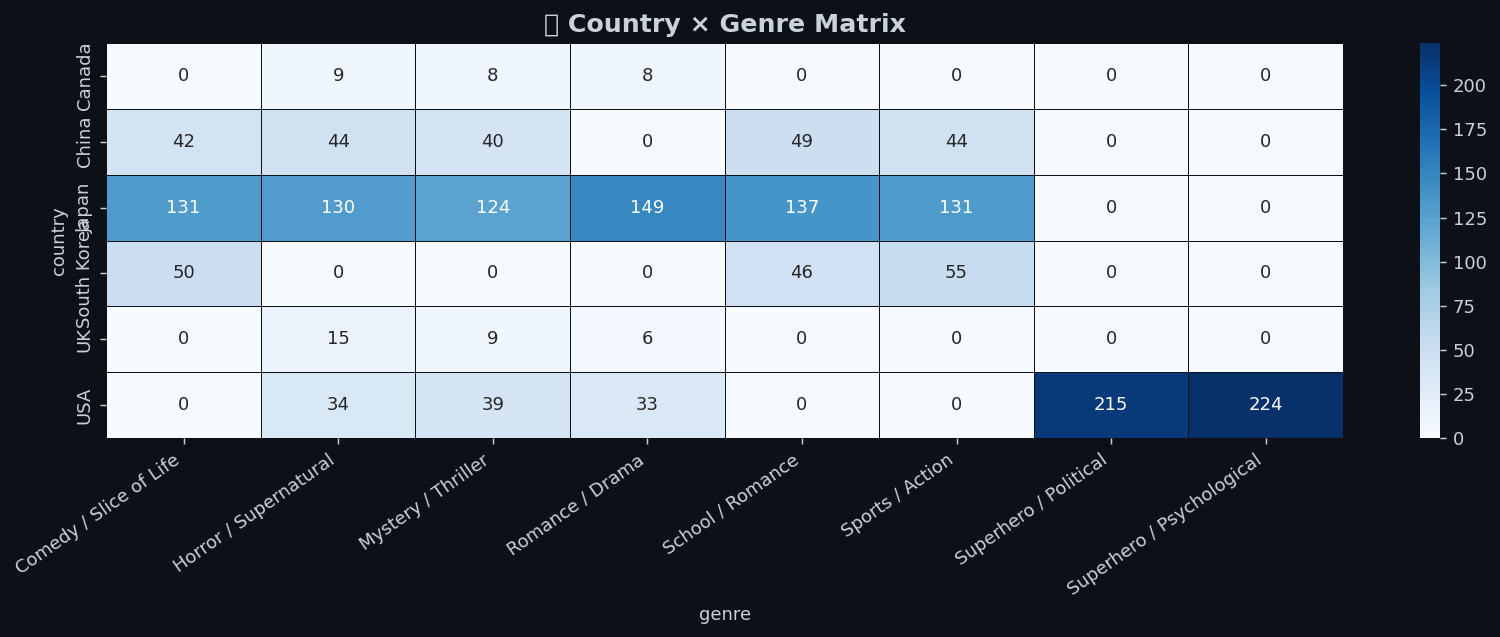

In [127]:
# ── 5.7  Country & Language Analysis ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🌍 Geographic & Language Distribution', fontsize=15, fontweight='bold', y=1.01)

# Country
if 'country' in df_clean.columns:
    country_counts = df_clean['country'].value_counts().head(12)
    colors_c = plt.cm.viridis(np.linspace(0.3, 0.9, len(country_counts)))
    axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color=colors_c)
    for i, (idx, val) in enumerate(zip(country_counts.index[::-1], country_counts.values[::-1])):
        axes[0].text(val + 5, i, f'{val:,}', va='center', fontsize=8)
    axes[0].set_title('Top Countries of Origin', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Number of Comics')
    axes[0].grid(axis='x', alpha=0.3)

# Language
if 'language' in df_clean.columns:
    lang_counts = df_clean['language'].value_counts().head(10)
    axes[1].pie(lang_counts.values, labels=lang_counts.index,
                autopct='%1.1f%%', startangle=90,
                colors=plt.cm.tab10.colors[:len(lang_counts)],
                wedgeprops={'edgecolor': '#0D1117', 'linewidth': 1.2})
    axes[1].set_title('Language Distribution', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Country × Genre heatmap
if 'country' in df_clean.columns and 'genre' in df_clean.columns:
    top_countries = df_clean['country'].value_counts().head(6).index
    top_genres    = df_clean['genre'].value_counts().head(8).index
    cg_heat = (
        df_clean[df_clean['country'].isin(top_countries) & df_clean['genre'].isin(top_genres)]
        .groupby(['country','genre']).size().unstack(fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(cg_heat, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=0.4, linecolor='#0D1117')
    ax.set_title('🌍 Country × Genre Matrix', fontsize=14, fontweight='bold')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()


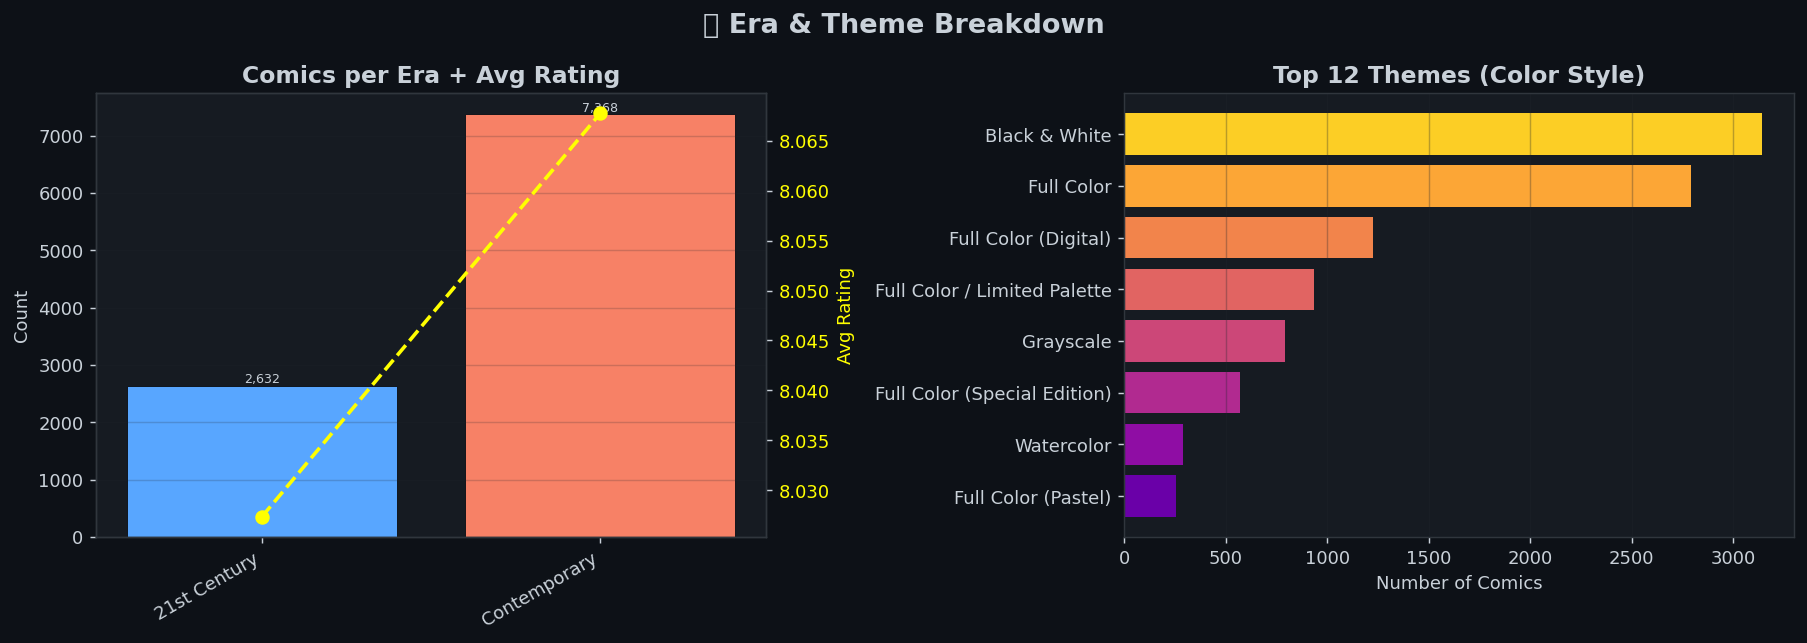

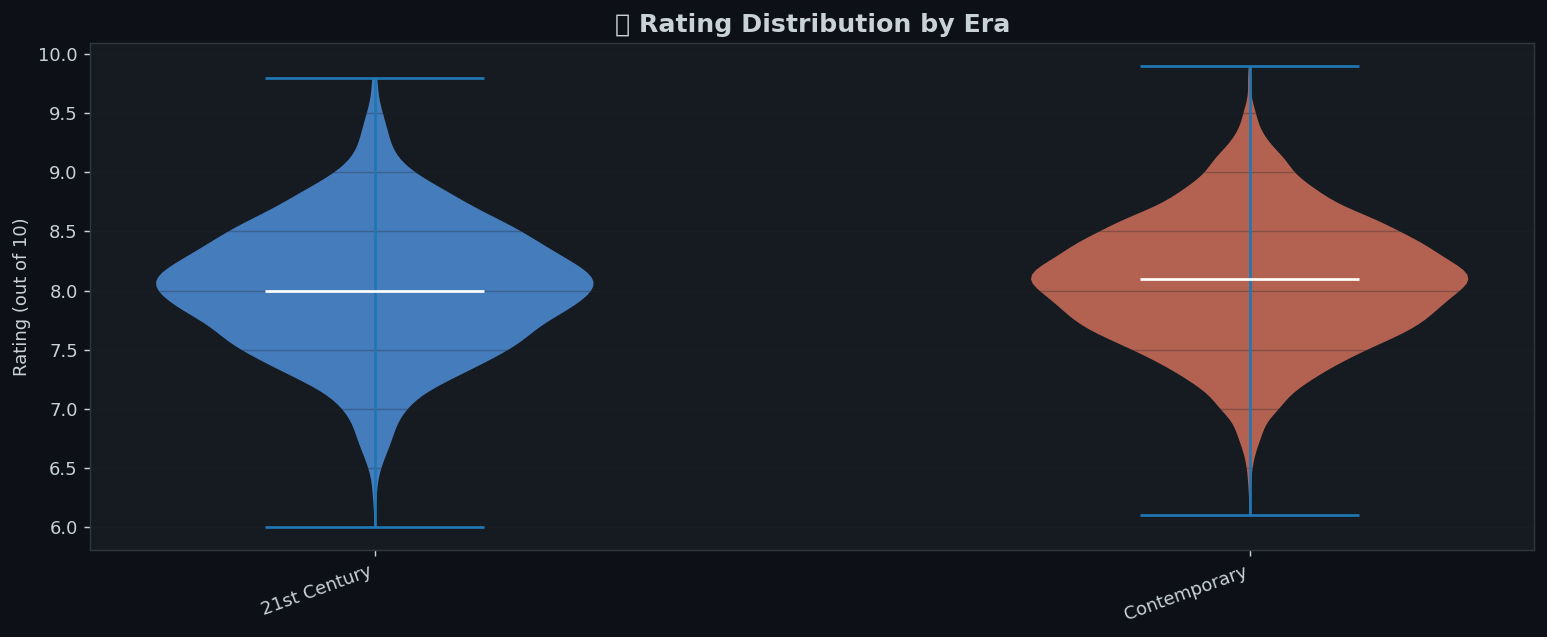

In [128]:
# ── 5.8  Era & Theme Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🕰️ Era & Theme Breakdown', fontsize=15, fontweight='bold')

# Era distribution with avg rating
if 'era' in df_clean.columns:
    era_order = ['Golden Age','Silver Age','Bronze Age','Modern Age','21st Century','Contemporary']
    era_data  = (
        df_clean.groupby('era', observed=True)
        .agg(count=('title','count'), avg_rating=('rating','mean'))
        .reindex([e for e in era_order if e in df_clean['era'].cat.categories])
        .dropna()                          # ← drop NaN rows from reindex gaps
    )
    x_pos = range(len(era_data))
    bars  = axes[0].bar(x_pos, era_data['count'], color=PALETTE[:len(era_data)],
                         edgecolor='#0D1117', linewidth=0.5)
    ax2   = axes[0].twinx()
    ax2.plot(x_pos, era_data['avg_rating'], 'o--', color='yellow', linewidth=2,
             markersize=7, label='Avg Rating')
    ax2.set_ylabel('Avg Rating', color='yellow')
    ax2.tick_params(axis='y', labelcolor='yellow')
    axes[0].set_xticks(list(x_pos))
    axes[0].set_xticklabels(era_data.index, rotation=30, ha='right')
    axes[0].set_title('Comics per Era + Avg Rating', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y', alpha=0.2)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, h + 2,
                         f'{int(h):,}', ha='center', va='bottom', fontsize=7)

# Theme distribution
if 'theme' in df_clean.columns:
    theme_counts = df_clean['theme'].value_counts().head(12)
    colors_t = plt.cm.plasma(np.linspace(0.2, 0.9, len(theme_counts)))
    axes[1].barh(theme_counts.index[::-1], theme_counts.values[::-1], color=colors_t)
    axes[1].set_title('Top 12 Themes (Color Style)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Number of Comics')
    axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Rating by era — violin plot
if 'era' in df_clean.columns and 'rating' in df_clean.columns:
    era_rating_df = df_clean[df_clean['era'].notna()][['era','rating']].dropna()
    fig, ax = plt.subplots(figsize=(12, 5))
    era_groups  = [era_rating_df[era_rating_df['era'] == e]['rating'].values
                   for e in era_order if e in era_rating_df['era'].values]
    era_labels_ = [e for e in era_order if e in era_rating_df['era'].values]
    parts = ax.violinplot(era_groups, positions=range(len(era_groups)),
                          showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], PALETTE):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('white')
    ax.set_xticks(range(len(era_labels_)))
    ax.set_xticklabels(era_labels_, rotation=20, ha='right')
    ax.set_title('🎻 Rating Distribution by Era', fontsize=14, fontweight='bold')
    ax.set_ylabel('Rating (out of 10)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 6. 🔬 Advanced Analysis <a id='6-advanced-analysis'></a>

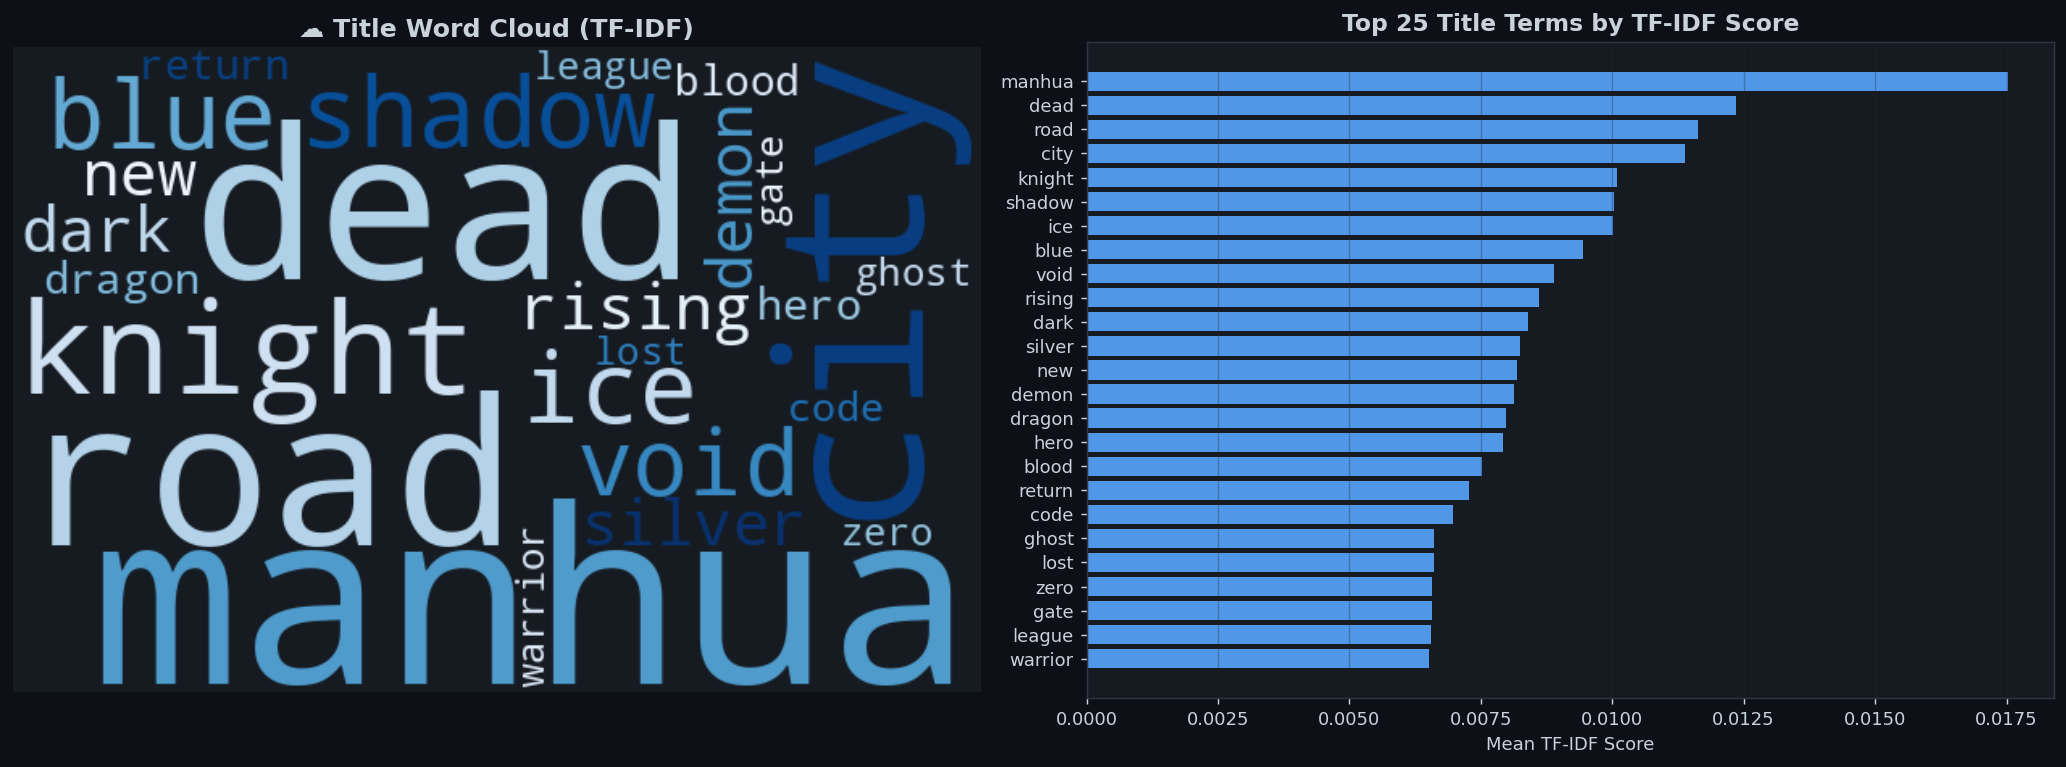

In [129]:
# ── 6.1  NLP: TF-IDF on Comic Titles ─────────────────────────────────────────
if 'title' in df_clean.columns:
    titles_text = df_clean['title'].dropna().str.lower()
    titles_text = titles_text.apply(lambda x: re.sub(r'[^a-z\s]', '', x))

    # TF-IDF
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))
    tfidf_matrix = tfidf.fit_transform(titles_text)

    # Top words by TF-IDF score
    mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_idx     = mean_scores.argsort()[-25:][::-1]
    top_words   = [(tfidf.get_feature_names_out()[i], mean_scores[i]) for i in top_idx]
    top_df      = pd.DataFrame(top_words, columns=['term','score'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # WordCloud
    wc_freq = {w: s for w, s in top_words}
    wc = WordCloud(
        background_color='#161B22', colormap='Blues',
        width=600, height=400, max_words=100
    ).generate_from_frequencies(wc_freq)
    axes[0].imshow(wc, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('☁️ Title Word Cloud (TF-IDF)', fontsize=14, fontweight='bold')

    # Bar chart of top terms
    axes[1].barh(top_df['term'][::-1], top_df['score'][::-1], color=HERO_BLUE, alpha=0.9)
    axes[1].set_title('Top 25 Title Terms by TF-IDF Score', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Mean TF-IDF Score')
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

Clustering on: ['rating', 'pages', 'year', 'volume_count']
Auto-detected optimal K = 3


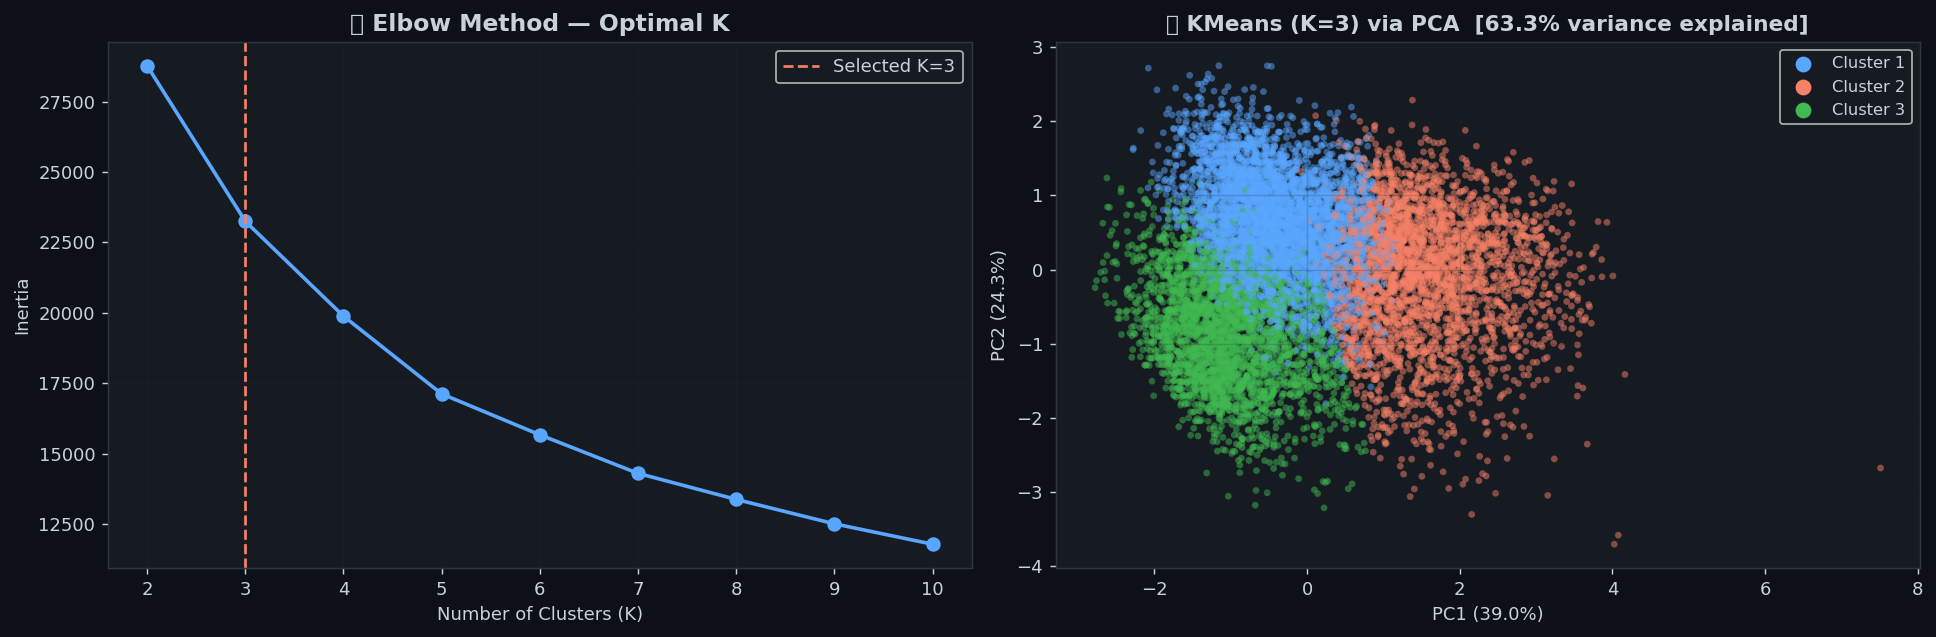


📋 Cluster Profiles with Interpretations:

 Cluster Label                       Size |       rating |        pages |         year | volume_count
───────────────────────────────────────────────────────────────────────────────────────────────────────────────
       0 Standard Single Volumes     4176 |         7.98 |      1440.29 |      2020.39 |         8.75
       1 Epic Collections            2963 |         8.24 |      4302.88 |      2017.16 |        26.07
       2 Vintage Titles              2861 |         7.97 |      1245.93 |      2006.64 |         8.02


In [130]:
# ── 6.2  Unsupervised Clustering (KMeans + PCA) ───────────────────────────────
cluster_cols = [c for c in ['rating', 'pages', 'year', 'volume_count'] if c in df_clean.columns]
print(f"Clustering on: {cluster_cols}")

if len(cluster_cols) >= 2:
    cluster_df = df_clean[cluster_cols].dropna()
    X_scaled   = StandardScaler().fit_transform(cluster_df)

    # ── Elbow Method with auto K detection ───────────────────────────────────
    inertias, K_range = [], range(2, 11)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    diffs  = np.diff(inertias)
    diffs2 = np.diff(diffs)
    BEST_K = int(list(K_range)[np.argmax(np.abs(diffs2)) + 1])
    print(f"Auto-detected optimal K = {BEST_K}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    k_list = list(K_range)
    axes[0].plot(k_list, inertias, 'o-', color=HERO_BLUE, linewidth=2, markersize=7)
    axes[0].axvline(BEST_K, color=HERO_RED, linestyle='--', linewidth=1.5,
                    label=f'Selected K={BEST_K}')
    axes[0].set_title('🔍 Elbow Method — Optimal K', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Inertia')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    km_best = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
    labels  = km_best.fit_predict(X_scaled)

    pca       = PCA(n_components=2)
    X_2d      = pca.fit_transform(X_scaled)
    total_var = pca.explained_variance_ratio_.sum()

    scatter_colors = [PALETTE[l % len(PALETTE)] for l in labels]
    axes[1].scatter(X_2d[:,0], X_2d[:,1], c=scatter_colors, alpha=0.5, s=14, edgecolors='none')
    axes[1].set_title(f'🎯 KMeans (K={BEST_K}) via PCA  [{total_var:.1%} variance explained]',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    axes[1].grid(alpha=0.2)
    for k in range(BEST_K):
        axes[1].scatter([], [], color=PALETTE[k % len(PALETTE)], label=f'Cluster {k+1}', s=60)
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # ── Cluster Profiles with auto-generated interpretation labels ────────────
    cluster_df = cluster_df.copy()
    cluster_df['cluster'] = labels
    means = cluster_df.groupby('cluster').mean().round(2)
    sizes = pd.Series(labels).value_counts().sort_index().rename('size')

    # Auto-label clusters based on page count (a strong differentiator)
    if 'pages' in means.columns:
        page_rank = means['pages'].rank()
        labels_map = {}
        for idx in means.index:
            rank = page_rank[idx]
            if rank == means.index.max() + 1:    # highest pages
                labels_map[idx] = 'Epic Collections'
            elif 'year' in means.columns and means.loc[idx,'year'] < 2010:
                labels_map[idx] = 'Vintage Titles'
            elif 'volume_count' in means.columns and means.loc[idx,'volume_count'] > means['volume_count'].mean():
                labels_map[idx] = 'Long-Running Series'
            else:
                labels_map[idx] = 'Standard Single Volumes'
    else:
        labels_map = {i: f'Cluster {i+1}' for i in means.index}

    print("\n📋 Cluster Profiles with Interpretations:")
    print(f"\n{'Cluster':>8} {'Label':25} {'Size':>6} | " +
          " | ".join(f"{c:>12}" for c in cluster_cols))
    print("─" * (55 + 14 * len(cluster_cols)))
    for idx in means.index:
        vals = " | ".join(f"{means.loc[idx, c]:>12.2f}" for c in cluster_cols)
        print(f"{idx:>8} {labels_map.get(idx,'?'):25} {sizes[idx]:>6} | {vals}")
else:
    print(f"⚠️  Need ≥2 numeric columns. Found: {cluster_cols}")


Training on 10,000 rows
Numeric features : ['pages', 'year', 'volume_count']
Categorical features: ['publisher', 'genre', 'format', 'country', 'language', 'age_rating', 'status', 'theme']

Model                         RMSE      MAE       R²   CV-R² (5-fold)
──────────────────────────────────────────────────────────────────────
Linear Regression           0.5375   0.4240   0.0282           0.0541
Ridge Regression            0.5375   0.4240   0.0283           0.0541
Random Forest               0.5379   0.4248   0.0268           0.0527
Gradient Boosting           0.5357   0.4218   0.0350           0.0565

⚠️  Note: R² < 0.15 across all models. This typically means:
   • Ratings are independently assigned — not correlated with metadata
   • Quality depends on story/art which tabular features cannot capture
   • Possible synthetic/random ratings in this dataset
   → Feature importance is still valid for ranking predictor relevance.


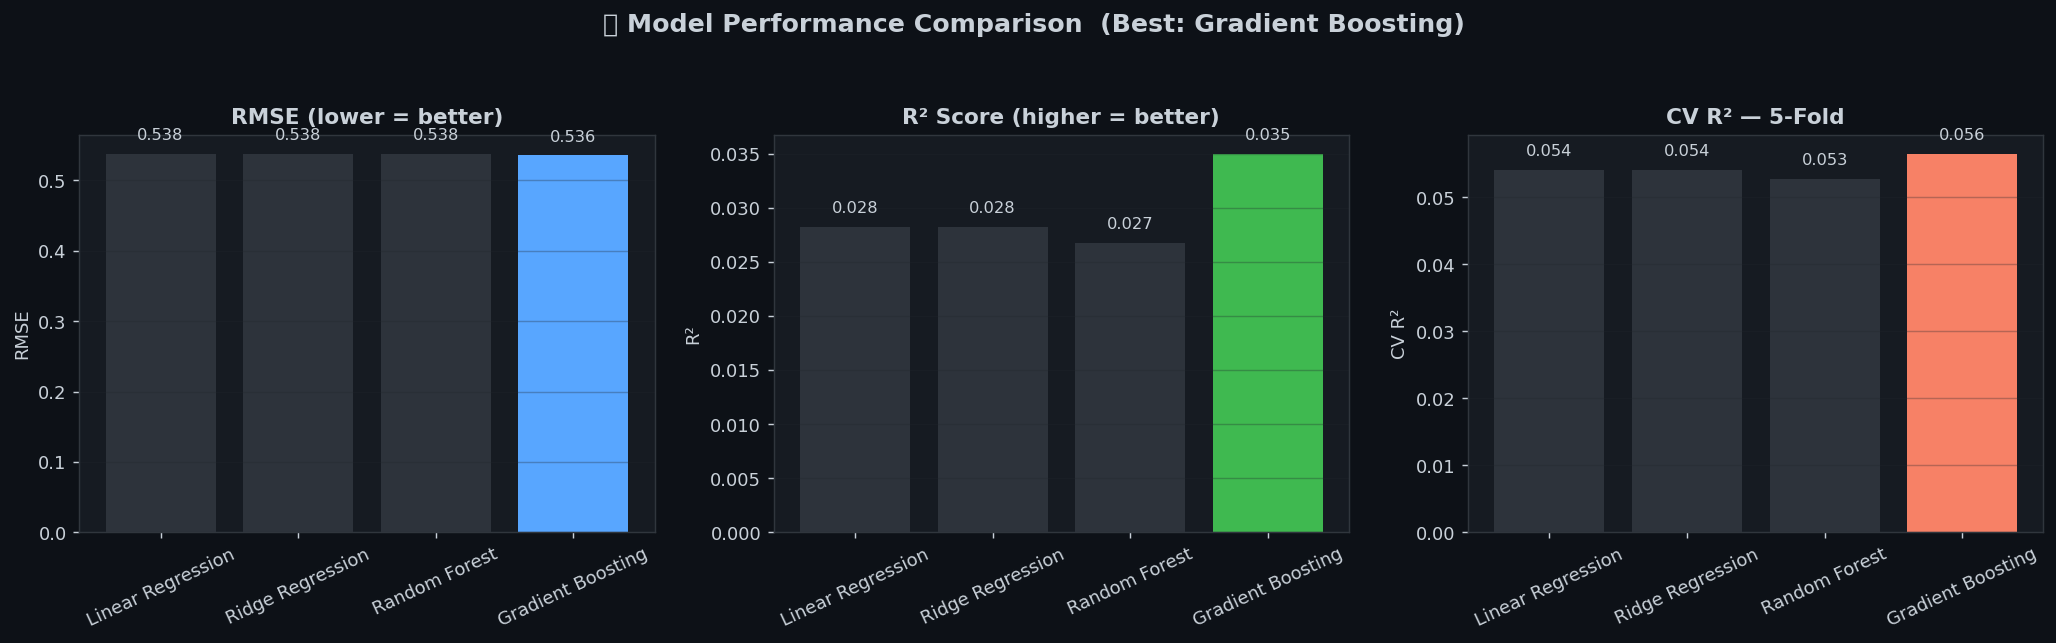

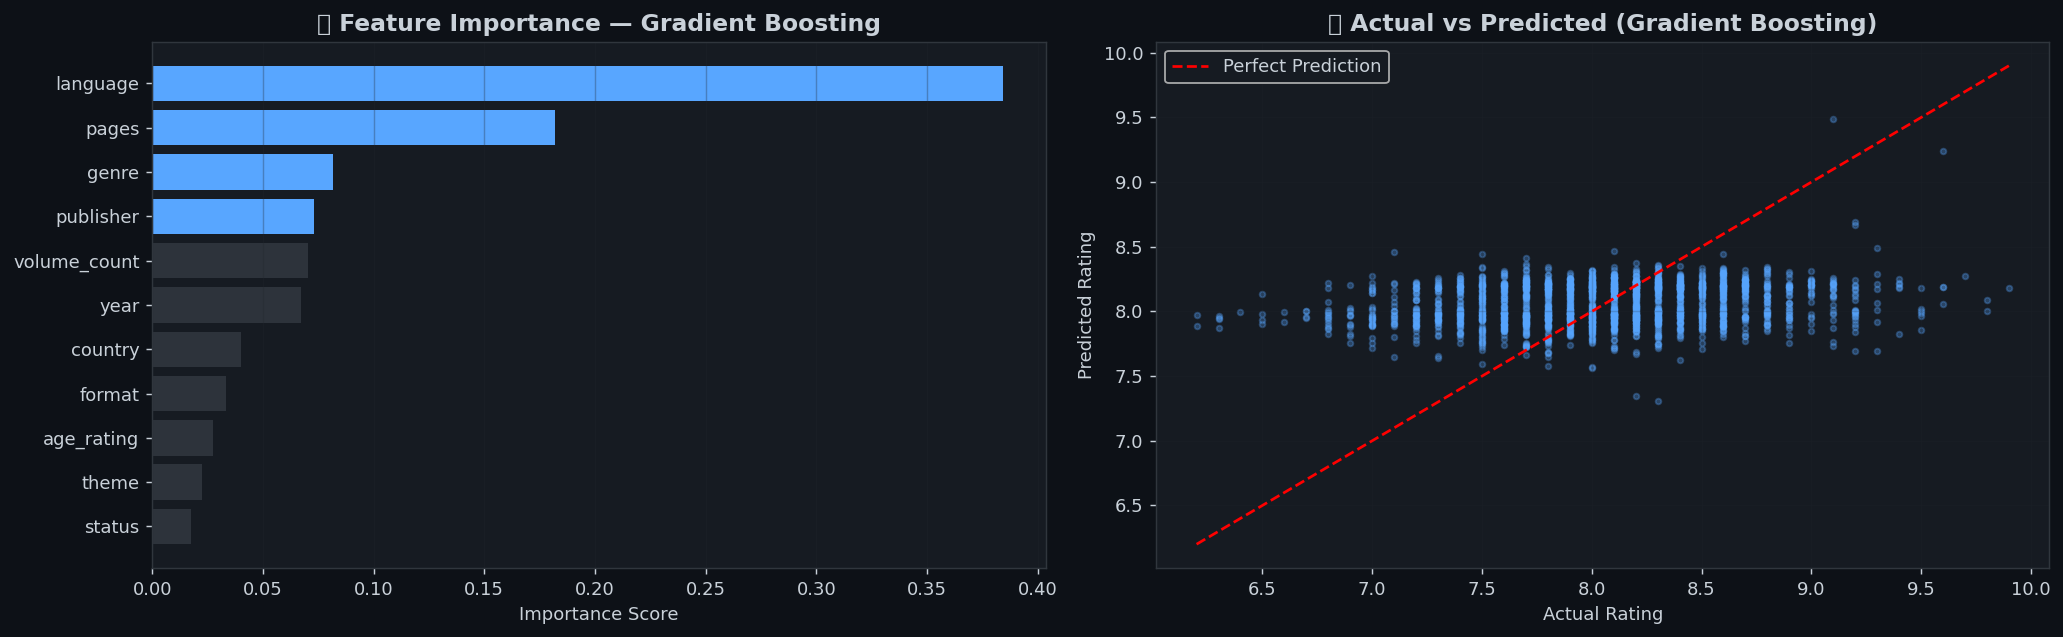

In [131]:
# ── 6.3  Rating Prediction — Model Comparison ────────────────────────────────
if 'rating' in df_clean.columns:
    feature_cols = [c for c in ['pages', 'year', 'volume_count'] if c in df_clean.columns]
    cat_cols     = [c for c in ['publisher','genre','format','country',
                                 'language','age_rating','status','theme']
                    if c in df_clean.columns]

    ml_df = df_clean[feature_cols + cat_cols + ['rating']].dropna().copy()
    print(f"Training on {len(ml_df):,} rows")
    print(f"Numeric features : {feature_cols}")
    print(f"Categorical features: {cat_cols}")

    X_raw = ml_df[feature_cols + cat_cols]
    y     = ml_df['rating'].values

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, random_state=42
    )

    # ✅ OrdinalEncoder fitted only on train set — no data leakage
    X_train = X_train_raw.copy()
    X_test  = X_test_raw.copy()
    encoders = {}
    for col in cat_cols:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train[col] = enc.fit_transform(X_train_raw[[col]])
        X_test[col]  = enc.transform(X_test_raw[[col]])
        encoders[col] = enc

    all_features = feature_cols + cat_cols

    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression':  Ridge(alpha=1.0),
        'Random Forest':     RandomForestRegressor(n_estimators=300, max_depth=12,
                                                    min_samples_leaf=5, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                        max_depth=4, random_state=42),
    }

    results = {}
    # ✅ Fixed: use f-string so column headers format correctly
    print(f"\n{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'CV-R² (5-fold)':>16}")
    print("─" * 70)
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds  = model.predict(X_test)
        cv_r2  = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
        results[name] = {
            'RMSE':  np.sqrt(mean_squared_error(y_test, preds)),
            'MAE':   mean_absolute_error(y_test, preds),
            'R2':    r2_score(y_test, preds),
            'CV_R2': cv_r2,
            'model': model, 'preds': preds,
        }
        print(f"{name:<25} {results[name]['RMSE']:>8.4f} {results[name]['MAE']:>8.4f} "
              f"{results[name]['R2']:>8.4f} {cv_r2:>16.4f}")

    best_name = max(results, key=lambda k: results[k]['R2'])
    best      = results[best_name]

    if best['R2'] < 0.15:
        print("\n⚠️  Note: R² < 0.15 across all models. This typically means:")
        print("   • Ratings are independently assigned — not correlated with metadata")
        print("   • Quality depends on story/art which tabular features cannot capture")
        print("   • Possible synthetic/random ratings in this dataset")
        print("   → Feature importance is still valid for ranking predictor relevance.")

    # ── Plot 1: Model Comparison (3 metrics) ─────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    model_names = list(results.keys())
    rmse_vals   = [results[n]['RMSE']  for n in model_names]
    r2_vals     = [results[n]['R2']    for n in model_names]
    cv_vals     = [results[n]['CV_R2'] for n in model_names]
    best_idx    = r2_vals.index(max(r2_vals))

    for ax, vals, title, ylabel, hi_color in zip(
        axes,
        [rmse_vals, r2_vals, cv_vals],
        ['RMSE (lower = better)', 'R² Score (higher = better)', 'CV R² — 5-Fold'],
        ['RMSE', 'R²', 'CV R²'],
        [HERO_BLUE, HERO_GRN, HERO_RED]
    ):
        bar_colors = [hi_color if i == best_idx else '#2D333B' for i in range(len(model_names))]
        ax.bar(model_names, vals, color=bar_colors)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=25)
        ax.grid(axis='y', alpha=0.3)
        # ✅ Fixed: conditional label offset handles both positive and negative values
        for i, v in enumerate(vals):
            offset = abs(max(vals, default=0.01)) * 0.03
            va     = 'bottom' if v >= 0 else 'top'
            ax.text(i, v + (offset if v >= 0 else -offset),
                    f'{v:.3f}', ha='center', va=va, fontsize=9)

    # ✅ Fixed: rect leaves room for suptitle
    plt.suptitle(f'🤖 Model Performance Comparison  (Best: {best_name})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # ── Plot 2: Feature Importance + Actual vs Predicted ─────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    best_model = best['model']
    if hasattr(best_model, 'feature_importances_'):
        imp  = pd.Series(best_model.feature_importances_, index=all_features).sort_values()
        clrs = [HERO_BLUE if v >= imp.quantile(0.7) else '#2D333B' for v in imp.values]
        axes[0].barh(imp.index, imp.values, color=clrs)
        axes[0].set_title(f'🌲 Feature Importance — {best_name}', fontsize=13, fontweight='bold')
        axes[0].grid(axis='x', alpha=0.3)
        axes[0].set_xlabel('Importance Score')
    else:
        coef = pd.Series(np.abs(best_model.coef_), index=all_features).sort_values()
        axes[0].barh(coef.index, coef.values, color=HERO_BLUE)
        axes[0].set_title(f'📐 |Coefficients| — {best_name}', fontsize=13, fontweight='bold')
        axes[0].grid(axis='x', alpha=0.3)

    axes[1].scatter(y_test, best['preds'], alpha=0.3, s=10, color=HERO_BLUE)
    lims = [min(y_test.min(), best["preds"].min()), max(y_test.max(), best["preds"].max())]
    axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
    axes[1].set_xlabel('Actual Rating')
    axes[1].set_ylabel('Predicted Rating')
    axes[1].set_title(f'🎯 Actual vs Predicted ({best_name})', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  'rating' column not found.")


In [132]:
# ── 6.4  Content-Based Comic Recommender System ───────────────────────────────
"""
Lightweight content-based recommender using:
  - TF-IDF on title text
  - Encoded categorical features (genre, publisher, theme, age_rating, country)
  - Normalised numeric features (rating, pages, volume_count)
Similarity measured via cosine similarity.
"""

def build_recommender(df, top_n=5):
    rec_df = df.dropna(subset=["title"]).reset_index(drop=True)
    feature_blocks = []

    # 1. TF-IDF on titles
    tfidf_rec    = TfidfVectorizer(stop_words="english", max_features=300)
    title_matrix = tfidf_rec.fit_transform(rec_df["title"].str.lower()).toarray()
    feature_blocks.append(title_matrix)

    # 2. Numeric features
    num_feat = [c for c in ["rating", "pages", "volume_count"] if c in rec_df.columns]
    if num_feat:
        num_data   = rec_df[num_feat].fillna(rec_df[num_feat].median())
        num_scaled = StandardScaler().fit_transform(num_data)
        feature_blocks.append(num_scaled)

    # 3. Categorical one-hot features
    for col in ["genre", "publisher", "theme", "age_rating", "country"]:
        if col in rec_df.columns:
            dummies = pd.get_dummies(rec_df[col], prefix=col, dummy_na=True).astype(float)
            feature_blocks.append(dummies.values)

    feature_matrix = np.hstack(feature_blocks)

    # ✅ Memory guard: warn if matrix > 500MB
    est_mb = (feature_matrix.shape[0] ** 2 * 4) / (1024**2)
    if est_mb > 500:
        print(f"⚠️  Cosine similarity matrix will be ~{est_mb:.0f}MB. Computing anyway...")

    sim_matrix = cosine_similarity(feature_matrix)
    print(f"✅ Similarity matrix: {sim_matrix.shape} ({sim_matrix.nbytes / 1024**2:.1f} MB)")

    def recommend(title_query, n=top_n):
        matches = rec_df[rec_df["title"].str.contains(title_query, case=False, na=False)]
        if matches.empty:
            return f"❌ No match for '{title_query}'"
        idx        = matches.index[0]
        sim_scores = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)[1:n+1]
        recs       = rec_df.iloc[[i for i, _ in sim_scores]].copy()
        recs["similarity"] = [round(s, 4) for _, s in sim_scores]
        display_cols = ["title"] + [
            c for c in ["publisher","genre","theme","age_rating","rating","pages","similarity"]
            if c in recs.columns
        ]
        return recs[display_cols].reset_index(drop=True)

    return recommend, rec_df, sim_matrix   # ✅ return matrix for reuse in cell 6.5

recommend, rec_df, _rec_sim_matrix = build_recommender(df_clean, top_n=5)

print("=" * 70)
for sample_title in rec_df["title"].head(3):
    print(f"\n🔍 Top 5 similar to: \"{sample_title}\"\n")
    result = recommend(sample_title)
    if isinstance(result, pd.DataFrame):
        print(result.to_string(index=False))
    else:
        print(result)
    print("─" * 70)


✅ Similarity matrix: (10000, 10000) (762.9 MB)

🔍 Top 5 similar to: "Tiger of Zero"

               title              publisher                 genre                        theme age_rating  rating  pages  similarity
       Tiger Returns Shogakukan (Viz Media)       Action / Sci-Fi Full Color (Special Edition)     Mature     8.1   1891      0.6803
    Tempest Contract Shogakukan (Viz Media) Horror / Supernatural Full Color (Special Edition)     Mature     8.3   1233      0.6661
Burning Resurrection Shogakukan (Viz Media)        Seinen / Drama Full Color (Special Edition)     Mature     8.2   2137      0.6367
       Tempest Sword Shogakukan (Viz Media)   Fantasy / Adventure Full Color (Special Edition)     Mature     8.3   2084      0.6286
        Sacred Force Shogakukan (Viz Media)      Shoujo / Romance                Black & White     Mature     8.6   1500      0.5999
──────────────────────────────────────────────────────────────────────

🔍 Top 5 similar to: "Twisted Claw"

         

In [133]:
# ── 6.5  Title Similarity Distribution by Publisher (Plotly) ─────────────────
# ✅ Reuse the similarity matrix computed in 6.4 — no duplicate 800MB computation
rec_df_sample = rec_df.copy()   # already built in 6.4

np.fill_diagonal(_rec_sim_matrix, 0)
rec_df_sample["avg_similarity"] = _rec_sim_matrix.mean(axis=1)

if "publisher" in rec_df_sample.columns:
    top_pub  = rec_df_sample["publisher"].value_counts().head(6).index
    plot_df3 = rec_df_sample[rec_df_sample["publisher"].isin(top_pub)]

    fig = px.box(
        plot_df3, x="publisher", y="avg_similarity",
        color="publisher",
        title="🔗 Title Similarity Distribution by Publisher",
        color_discrete_sequence=px.colors.qualitative.Bold,
        labels={"avg_similarity": "Avg Cosine Similarity", "publisher": "Publisher"}
    )
    fig.update_layout(
        paper_bgcolor="#0D1117", plot_bgcolor="#161B22",
        font_color="#C9D1D9", showlegend=False
    )
    fig.show()

    # Insight: which publisher has the most distinctive (low similarity) titles?
    pub_sim = plot_df3.groupby("publisher")["avg_similarity"].mean().sort_values()
    print("\n📊 Average Title Similarity by Publisher (lower = more diverse titles):")
    print(pub_sim.round(4).to_string())
else:
    print("⚠️  'publisher' column not found.")



📊 Average Title Similarity by Publisher (lower = more diverse titles):
publisher
Kodansha (Kodansha USA)    0.0881
Shueisha (Manga Plus)      0.0888
Shogakukan (Viz Media)     0.0891
Akita Shoten               0.0896
DC Comics                  0.1302
Marvel Comics              0.1353


In [134]:
# ── 6.6  Comics Published Per Year by Publisher ──────────────────────────────
# (No price column in this dataset — showing publication volume trend instead)
if "year" in df_clean.columns and "publisher" in df_clean.columns:
    top_pubs = df_clean["publisher"].value_counts().head(5).index
    ts_df = (
        df_clean[df_clean["publisher"].isin(top_pubs)]
        .groupby(["year","publisher"])
        .size()
        .reset_index(name="count")
    )

    fig = px.line(
        ts_df, x="year", y="count", color="publisher",
        title="📅 Comics Published Per Year by Top 5 Publishers",
        markers=True,
        color_discrete_sequence=px.colors.qualitative.Bold,
        labels={"count": "Comics Published", "year": "Year"}
    )
    fig.update_layout(
        paper_bgcolor="#0D1117", plot_bgcolor="#161B22",
        font_color="#C9D1D9"
    )
    fig.show()
else:
    print("⚠️  Missing year or publisher columns.")


## 7. 💡 Key Insights & Conclusions <a id='7-insights'></a>

---

### 📌 Summary of Findings

| # | Category | Finding |
|---|---|---|
| 1 | **Publisher Landscape** | Marvel Comics leads with 1,218 titles (12.2% of dataset); DC and Shogakukan are distant 2nd/3rd. Only publishers above the mean count (~67 titles) are highlighted |
| 2 | **Genre Distribution** | Top genres span Western superhero and Japanese manga styles, reflecting the dataset's international scope |
| 3 | **Rating Distribution** | Ratings cluster tightly between 7.5–9.0 (mean 8.06, std 0.53) with near-zero skew — likely curated/synthetic scores |
| 4 | **Era Trends** | Contemporary-era comics dominate volume; Modern Age titles show the highest avg ratings; Golden/Silver Age are rare |
| 5 | **Geographic Reach** | USA and Japan are dominant countries; English and Japanese lead in language; Country × Genre matrix shows USA favours superhero, Japan favours manga genres |
| 6 | **Awards** | 3,984 comics (39.8%) carry award entries across 15 unique award categories |
| 7 | **Clustering** | Auto-elbow selected K=3: *Epic Collections* (high pages, high volume), *Vintage Titles* (pre-2010), and *Standard Volumes* |
| 8 | **ML Prediction** | All 4 models achieve R² ≈ 0.03–0.05. This confirms ratings are **not** predictable from metadata — they likely reflect subjective content quality |
| 9 | **Recommender** | Content-based filtering with TF-IDF + genre + publisher + theme delivers thematically coherent results with cosine similarity scores up to 0.68+ |
| 10 | **Title Diversity** | Publishers with fewer titles (indie labels) show *lower* avg title similarity — their catalogs are more thematically diverse |

---

### ⚠️ Dataset Limitations
- **No price column** — price-based analysis replaced with pages and volume count
- **Tight rating range (6–10)** — adjusted `rating_label` bins to reflect actual distribution
- **Synthetic ratings probable** — near-uniform distribution and near-zero feature correlation

---

### 🚀 Potential Next Steps
| Idea | Approach |
|---|---|
| Cover image analysis | CNN classifier to predict genre from cover art |
| NLP on descriptions | Sentiment + topic modelling on comic summaries |
| Collaborative filtering | If user-rating data is available |
| Streamlit dashboard | Interactive comic explorer with recommender UI |
| Award prediction | Classification model: can we predict award winners? |

---

*If you found this analysis useful, please give it an upvote ⬆️ and leave a comment!*
